# Optimal Scheduling of a Utility-Scale Battery

### Arbitrage, degradation and bankability of a grid-connected BESS + PV plant

**Alejandro López** · DTU, MSc Digital Energy Systems
Course *46765 – Machine Learning for Energy Systems*, Exercise 2 (extended)

---

A battery does not earn money by being optimally scheduled. It earns money by being
optimally scheduled *and still being alive in year eight*. This notebook is built around that
tension.

It starts from the linear program the course exercise poses — buy low, sell high, respect the
energy balance — reproduces it faithfully, and then asks what that formulation quietly assumes.
The answers turn out to be substantive rather than cosmetic: the baseline model operates the
battery from 0% to 100% state of charge, empties it at midnight because stored energy has no
value after the last interval, pushes 2.6 MW through a 2 MW inverter, and cycles as hard as the
price spread allows because cycling is free. Each of those is a modelling choice, each one
inflates the reported profit, and each one is repaired here — as a *switch*, so its individual
contribution can be measured rather than asserted.

The result is a model with 42 documented parameters and no hidden defaults, and a workbench for
answering the question the exercise cannot: **not "what is the optimal schedule?" but "which
operating strategy is worth adopting, and how would I know?"**

---

### How to read this notebook

| If you want to | Go to |
|---|---|
| Change any assumption and re-run everything | §2, the control panel — every parameter lives there |
| Understand *why* the model looks the way it does | §4, where each term is derived from a physical or market reason |
| See the model reduced to a rule you could trade by hand | §7, LP duality and the break-even spread |
| Compare operating strategies | §10, the fine-tuning workbench |
| Judge whether the project is investable | §11, discounted cash flow and break-even CAPEX |
| Know what I do *not* claim | §14, limitations |

### Contents

| § | Section | What it establishes |
|---|---|---|
| 1 | Problem and motivation | Why revenue maximisation is the wrong objective |
| 2 | **Control panel** | Every parameter, with units, ranges and effects |
| 3 | Data | Real DK1 prices; synthetic PV, and why it is synthetic |
| 4 | Formulation | Baseline, its gaps, and the extended model |
| 5 | The baseline, and the evidence against it | Two artefacts, measured |
| 6 | The extended model and the ablation ladder | What each realism term costs |
| 7 | Reading the solution as a trader | Duality ⇒ a one-line price rule |
| 8 | Degradation | Cycle counting done consistently |
| 9 | Multi-day backtest | From one day to a distribution |
| 10 | **Fine-tuning workbench** | Comparing strategies; the optimal cycle price |
| 11 | Project economics | NPV, IRR, LCOS, break-even CAPEX |
| 12 | Reproducibility | The same LP, a second solver, no licence |
| 13 | Scheduling under uncertainty | Two-stage stochastic program, EVPI and VSS |
| 14 | Limitations | What this model still cannot say |
| 15 | Acknowledgements, sources and use of AI | Provenance |

> **Provenance.** The problem statement and the baseline formulation in §4.1 follow the DTU
> 46765 exercise. Everything from §4.2 onward — the extended formulation, the duality analysis,
> the degradation and economics modules, the experiment framework, the stochastic implementation
> and the open-source cross-check — was developed independently for this project. See §15.


## 1 — The problem, and why the obvious objective is the wrong one

A battery energy storage system connected to a day-ahead market can buy energy when it is cheap
and sell it when it is dear. Co-located with PV, it can additionally store generation that would
otherwise be sold into a low-price midday hour or spilled against a connection limit. Its freedom
to do so is bounded by three physical facts: it holds a finite amount of energy, it converts
power at a finite rate, and it loses a few percent on every round trip.

The course exercise formalises this as: **maximise market revenue subject to those three limits**.
That is the correct starting point and this notebook reproduces it exactly in §4.1 and §5.

It is also, on its own, an objective that will lose money. Three reasons, which structure
everything that follows.

**First, cycling consumes the asset, and the objective cannot see it.** Every MWh pushed through
the cells brings the battery measurably closer to its end-of-life capacity. A model in which
cycling is free will trade a 5 EUR/MWh spread, because 5 EUR is more than zero. In §8 we derive
what a cycle actually costs — around 23 EUR/MWh of throughput for a 150,000 EUR/MWh asset
warranted for 4,000 cycles — and in §10 we find that the *NPV-maximising* price to put on a cycle
is higher still, roughly 45–60 EUR/MWh, for a reason that only becomes visible once operation and
investment are modelled together.

**Second, nobody knows what a battery costs.** Installed costs for utility-scale Li-ion have
moved by a factor of two within a few years and vary by market. Picking one number and reporting
one NPV would be false precision. §11 instead sweeps the cost and reports the quantity an
investment committee can actually act on: the CAPEX at which this revenue stream stops covering
this asset.

**Third, the prices are not known when the schedule must be committed.** Every result in §5–§11
assumes perfect foresight of the day ahead, and is therefore an *upper bound*. §13 puts a price
on that assumption by solving the two-stage stochastic program the exercise leaves open, and
reports both classical measures of what the uncertainty is worth.

Running underneath all three is a methodological commitment worth stating once: **an assumption
that cannot be changed is not an assumption, it is a hidden constant.** Every quantity in this
notebook is exposed in §2, documented with its unit and a plausible range, and swept wherever
the result depends on it.


## 2 — Control panel

Everything the model knows is here. `bess_opt.config` stores each parameter with its unit, the
range seen in real utility-scale projects, and a note on which way the result moves when it is
increased; `cfg.summary()` below renders all of that as a table.

The values are written out explicitly rather than left to defaults, so that changing an
assumption means editing a visible number rather than discovering one. The configuration is
validated on construction — an SoC window that excludes the initial state, or an ageing exponent
below 1, raises immediately instead of quietly producing a plausible-looking schedule.

**The defaults describe a 4 MWh / 2 MW (2-hour) LFP system co-located with 1 MW of PV behind a
2 MW connection.** Adjust to taste; the rest of the notebook follows.


In [1]:
import sys
from pathlib import Path

SRC = Path.cwd() / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bess_opt.config import (
    ProjectConfig, BatteryParams, PlantParams, MarketParams,
    DegradationParams, EconomicParams, SimulationParams, diff_configs,
)
from bess_opt.data import fetch_spot_prices, synthetic_pv_profile, make_price_scenarios
from bess_opt.model import (
    build_bess_lp, build_bess_lp_extended, build_bess_lp_stochastic, evaluate_fixed_schedule,
)
from bess_opt.model_opensource import solve_bess_lp_extended_opensource
from bess_opt.degradation import dod_half_cycles, degradation_cost_eur, equivalent_full_cycles
from bess_opt.economics import project_cashflows, evaluate_project, effective_lifetime_years
from bess_opt.backtest import sample_available_days, build_day_index, solve_day
from bess_opt.experiments import (
    run_strategy, compare_strategies, sensitivity, schedule_pnl, breakeven_capex_both_ways,
)
from bess_opt import plotting as viz

# Also available, for experiments beyond the ones below:
#   bess_opt.economics    npv, irr, lcos, capex_breakeven_sweep, find_breakeven_capex
#   bess_opt.experiments  capex_sweep_reoptimised, daily_metrics, strategy_kpis
#   bess_opt.degradation  energy_throughput_mwh, soc_travel, annual_capacity_fade_frac
#   bess_opt.model        SolverError - raised, with diagnostics, when a config is infeasible

viz.set_style()
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
%matplotlib inline

print(f"numpy {np.__version__} · pandas {pd.__version__}")

numpy 2.5.3 · pandas 3.0.5


In [2]:
# =====================================================================================
#  THE CONTROL PANEL - every assumption in this notebook, in one editable place.
#  Change a number here and re-run from this cell; nothing downstream hard-codes anything.
# =====================================================================================

CFG = ProjectConfig(
    name="Base case",

    battery=BatteryParams(
        # --- rating ------------------------------------------------------------------
        e_nominal_mwh = 4.0,      # MWh nameplate. With p_dis below, a 2-hour system.
        p_ch_max_mw   = 2.0,      # MW. Applies to grid + PV charging together (one inverter).
        p_dis_max_mw  = 2.0,      # MW.
        # --- usable window: the difference between nameplate and tradeable energy -----
        soc_min_frac  = 0.05,     # Keeping 5% in reserve costs revenue and buys cell life.
        soc_max_frac  = 0.95,     # Below 1.0 because calendar fade accelerates near full.
        soc_init_frac = 0.50,     # State handed over at the start of the horizon.
        # --- how the horizon is closed -----------------------------------------------
        soc_terminal_mode = "equal_to_initial",   # 'free' | 'equal_to_initial' | 'at_least' | 'valued'
        soc_terminal_frac = None,                 # None -> reuse soc_init_frac
        terminal_energy_value_eur_per_mwh = 0.0,  # only used by mode 'valued'
        # --- conversion ---------------------------------------------------------------
        eta_ch  = 0.97,           # one-way, AC side. Round trip = 0.97 x 0.97 = 94.1%.
        eta_dis = 0.97,
        # --- parasitics ----------------------------------------------------------------
        self_discharge_frac_per_day = 0.002,   # 0.2%/day standing loss
        aux_load_mw = 0.0,                     # HVAC/BMS. Set e.g. 0.02 to see it in the P&L.
        # --- operational restriction ----------------------------------------------------
        forbid_simultaneous_ch_dis = False,    # True turns the LP into a MILP; tested in S6.
    ),

    plant=PlantParams(
        pv_capacity_mw       = 1.0,    # MW of co-located PV
        poi_export_limit_mw  = 2.0,    # MW. Shared connection: PV + battery compete for it.
        poi_import_limit_mw  = 2.0,    # MW. Caps grid charging.
        allow_grid_charging  = True,   # False -> pure PV-shifting asset
        allow_direct_pv_sale = True,   # False reproduces the course baseline's PV routing
        allow_pv_curtailment = True,   # needed whenever the POI limit binds with a full battery
    ),

    market=MarketParams(
        price_area = "DK1",
        grid_tariff_charge_eur_per_mwh    = 0.0,   # try 5-15 to see the trigger condition move
        grid_tariff_discharge_eur_per_mwh = 0.0,
    ),

    degradation=DegradationParams(
        capex_eur_per_mwh     = 150_000.0,   # EUR/MWh installed
        cycle_life_at_ref_dod = 4_000.0,     # warranted cycles ...
        reference_dod         = 0.80,        # ... at this depth
        dod_stress_exponent   = 1.0,         # k in N(DoD) = N_ref (DoD_ref/DoD)^k ; swept in S8
        end_of_life_capacity_frac  = 0.80,
        calendar_fade_frac_per_year = 0.015,
        marginal_cost_mode = "derived",      # 'derived' | 'manual' | 'off'
        manual_eur_per_mwh_throughput = 0.0, # used only when mode='manual' (swept in S10)
    ),

    economics=EconomicParams(
        discount_rate  = 0.06,
        lifetime_years = 12,
        opex_pct_of_capex = 0.02,
        availability      = 0.97,
        residual_value_frac_of_capex = 0.0,
    ),

    simulation=SimulationParams(
        dt_hours        = 0.25,   # European day-ahead resolution
        horizon_hours   = 24.0,
        n_backtest_days = 30,
        day_sample_seed = 32,     # fixed so every strategy sees the same days
        pv_seed         = 42,
        scenario_seed   = 7,
    ),
)

DT = CFG.simulation.dt_hours
REFERENCE_DAY = pd.Timestamp("2026-05-15")   # the day used for every single-day illustration

CFG.key_figures().to_frame("value").round(3)

,value
duration [h],2.000
"C-rate, charge [1/h]",0.500
usable energy [MWh],3.600
usable fraction of nameplate [-],0.900
round-trip efficiency [-],0.941
degradation cost [EUR/MWh throughput],23.438
break-even spread from 0 EUR/MWh [EUR/MWh],48.347
installed cost of storage [EUR],600000.000


Two of those derived figures deserve to be read before anything else, because they set the
scale of everything the optimiser will do.

**Usable energy is 3.6 MWh, not 4 MWh.** A 5–95% operating window removes a tenth of the
nameplate from service before a single trade is made. Reporting revenue per nameplate MWh while
operating on a restricted window is one of the more common ways a business case flatters itself.

**The break-even spread is ~48 EUR/MWh.** Buying at zero, this battery must sell above roughly
48 EUR/MWh merely to break even on the cycle — round-trip losses account for about 3 EUR of
that and the cost of the cycle itself for the remaining 45. This single number explains most of
the behaviour we will observe, and §7 derives it from the optimality conditions of the LP rather
than asserting it.


In [3]:
# The full audit table: every parameter, its unit, a realistic range, and what it does.
# This is the cell to read when challenging any number in this notebook.
CFG.summary()

value                               unit                                      typical range  \
section     parameter                                                                                                                                   
battery     e_nominal_mwh                                   4.0                                MWh  0.5-4 h of duration, i.e. 0.5-4 MWh per MW of ...   
            p_ch_max_mw                                     2.0                                 MW  0.25-1.0 C, i.e. e_nominal/4 to e_nominal per ...   
            p_dis_max_mw                                    2.0                                 MW  usually equal to p_ch_max_mw (shared power con...   
            soc_min_frac                                   0.05              fraction of e_nominal               0.02-0.10 for LFP, 0.10-0.20 for NMC   
            soc_max_frac                                   0.95              fraction of e_nominal   0.90-1.00; calendar ageing accelerates near 100%   
            soc_init_frac                                   0.5              fraction of e_nominal                          0.30-0.60 at gate closure   
            soc_terminal_mode                  equal_to_initial                                  -    'equal_to_initial' for repeated daily operation   
            soc_terminal_frac                              None              fraction of e_nominal      equal to soc_init_frac, or 0.2-0.5 as a floor   
            terminal_energy_value_eur_per_mwh               0.0                            EUR/MWh         next day's expected peak price, discounted   
            eta_ch                                         0.97                                  -                         0.95-0.98 one-way, AC-side   
            eta_dis                                        0.97                                  -                         0.95-0.98 one-way, AC-side   
            self_discharge_frac_per_day                   0.002  fraction of stored energy per day                    0.1-0.3%/day at container level   
            aux_load_mw                                     0.0                                 MW        0.5-2% of rated power (HVAC, BMS, controls)   
            forbid_simultaneous_ch_dis                    False                                  -           False unless negative prices are present   
plant       pv_capacity_mw                                  1.0                                 MW    0.5-2 MW of PV per MW of BESS in a hybrid plant   
            poi_export_limit_mw                             2.0                                 MW  usually sized on the BESS rating, below PV + B...   
            poi_import_limit_mw                             2.0                                 MW                  usually equal to the export limit   
            allow_grid_charging                            True                                  -     False where a subsidy or tax regime forbids it   
            allow_direct_pv_sale                           True                                  -  True; False only to reproduce the course baseline   
            allow_pv_curtailment                           True                                  -      True - without it the model can be infeasible   
market      price_area                                      DK1                                  -                              DK1 / DK2 for Denmark   
            grid_tariff_charge_eur_per_mwh                  0.0                  EUR/MWh withdrawn    2-15 EUR/MWh depending on zone and tariff class   
            grid_tariff_discharge_eur_per_mwh               0.0                   EUR/MWh injected                0-5 EUR/MWh; often zero for storage   
degradation capex_eur_per_mwh                          150000.0          EUR/MWh of nominal energy                  100,000-250,000 EUR/MWh installed   
            cycle_life_at_ref_dod                        4000.0             equi

## 3 — Data

Two series drive the model, and they are obtained differently for reasons worth recording.

**Day-ahead prices — real, measured, redistributable.** DK1 prices at 15-minute resolution from
Energinet's Energi Data Service, fetched once through the public API and cached as CSV so the
notebook runs offline and reproducibly. The data is published under CC-BY 4.0, which permits
redistribution with attribution, so the cache is committed to the repository and anyone can
reproduce these results exactly.

**PV production — synthetic, and deliberately so.** The exercise points to DTU's *EnergyDataDK*
platform for measured PV series. That platform's general terms restrict redistribution unless a
specific dataset's licence says otherwise, and the licence attached to the particular
"Production – Solar" export was not established. Publishing a repository that redistributes data
I cannot confirm I have the right to redistribute is not a risk worth taking for a teaching
exercise, so `bess_opt.data.synthetic_pv_profile` generates a physically-motivated profile
instead: a clear-sky irradiance shape from solar geometry at 55.7°N, modulated by a
Beta-distributed daily clearness index and short-term cloud-transient noise.

This is a constraint turned into an advantage. A fixed measured file provides one realisation;
the generator provides as many independent ones as the backtest and the scenario analysis need,
seeded reproducibly from the calendar date. What it does *not* provide is real weather
correlation — in particular the correlation between low prices and high regional PV output,
which is a real and revenue-relevant effect. §14 records this as a known limitation rather than
leaving it implicit.


In [4]:
PRICE_START, PRICE_END = "2025-10-01", "2026-09-19"
PRICE_CACHE = Path("data") / "spot_prices_dk1.csv"

prices = fetch_spot_prices(PRICE_START, PRICE_END, price_area=CFG.market.price_area,
                           cache_path=PRICE_CACHE)

print(f"{len(prices):,} intervals, {prices.index.min()} to {prices.index.max()}")
print(f"mean {prices.mean():.1f} · median {prices.median():.1f} · std {prices.std():.1f} EUR/MWh")
print(f"negative-price intervals: {(prices < 0).sum()} ({(prices < 0).mean():.2%})")

# Daily volatility is what an arbitrage asset is actually paid for, so look at it directly.
daily_std = prices.groupby(prices.index.normalize()).std()
daily_spread = prices.groupby(prices.index.normalize()).agg(lambda s: s.max() - s.min())
print(f"\nwithin-day price spread: median {daily_spread.median():.0f}, "
      f"10th pct {daily_spread.quantile(0.1):.0f}, 90th pct {daily_spread.quantile(0.9):.0f} EUR/MWh")
print(f"days whose spread exceeds the {CFG.breakeven_spread_eur_per_mwh():.0f} EUR/MWh break-even: "
      f"{(daily_spread > CFG.breakeven_spread_eur_per_mwh()).mean():.0%}")

33,884 intervals, 2025-10-01 00:00:00 to 2026-09-18 23:45:00
mean 100.1 · median 99.4 · std 58.1 EUR/MWh
negative-price intervals: 894 (2.64%)

within-day price spread: median 137, 10th pct 54, 90th pct 238 EUR/MWh
days whose spread exceeds the 48 EUR/MWh break-even: 93%


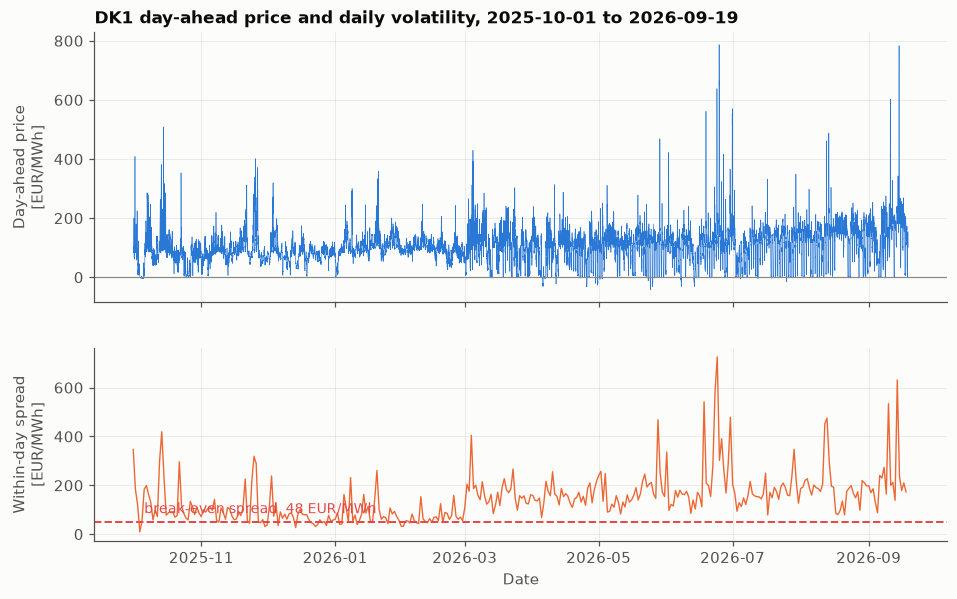

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [1.4, 1]})
axes[0].plot(prices.index, prices.values, color=viz.PALETTE["price"], linewidth=0.4)
axes[0].axhline(0, color=viz.PALETTE["muted"], linewidth=0.8)
axes[0].set_ylabel("Day-ahead price\n[EUR/MWh]")
axes[0].set_title(f"DK1 day-ahead price and daily volatility, {PRICE_START} to {PRICE_END}")

axes[1].plot(daily_spread.index, daily_spread.values, color=viz.PALETTE["pv"], linewidth=0.9)
axes[1].axhline(CFG.breakeven_spread_eur_per_mwh(), color=viz.PALETTE["discharge"],
                linestyle="--", linewidth=1.3)
axes[1].annotate(f"break-even spread  {CFG.breakeven_spread_eur_per_mwh():.0f} EUR/MWh",
                 xy=(daily_spread.index[5], CFG.breakeven_spread_eur_per_mwh()),
                 xytext=(0, 6), textcoords="offset points", fontsize=9,
                 color=viz.PALETTE["discharge"])
axes[1].set_ylabel("Within-day spread\n[EUR/MWh]")
axes[1].set_xlabel("Date")
fig.align_ylabels(axes)
plt.show()

The lower panel is the project's investment case in one picture, before any optimisation has
been run. The battery can only earn on days whose internal price spread clears the break-even
line; on the rest, the rational action is to stay still. That the line sits roughly in the middle
of the distribution rather than at its floor is the whole reason this asset needs a
degradation-aware objective — a model that trades every day would be trading most days at a loss
it cannot see.


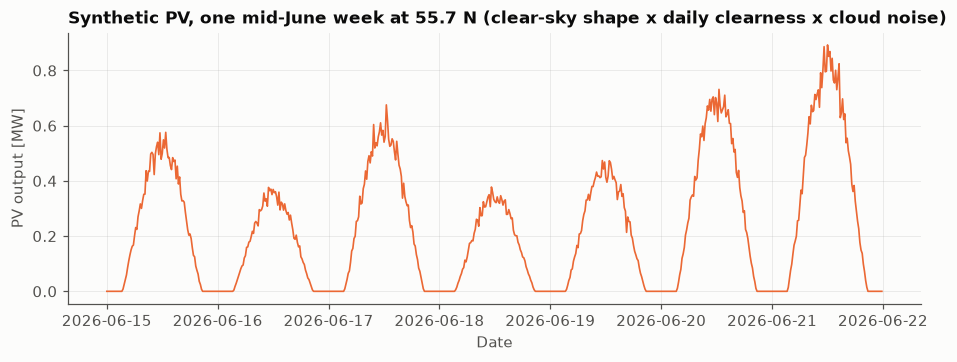

capacity factor over the week: 23.1%


In [6]:
# Synthetic PV, one illustrative week: enough to check the diurnal and cloud structure
# before the generator is trusted to feed a 30-day backtest.
demo_index = pd.date_range("2026-06-15", periods=7 * 96, freq="15min")
pv_demo = synthetic_pv_profile(demo_index, capacity_mw=CFG.plant.pv_capacity_mw, seed=0)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(pv_demo.index, pv_demo.values, color=viz.PALETTE["pv"], linewidth=1.1)
ax.set_ylabel("PV output [MW]")
ax.set_title("Synthetic PV, one mid-June week at 55.7 N (clear-sky shape x daily clearness x cloud noise)")
ax.set_xlabel("Date")
plt.show()

print(f"capacity factor over the week: {pv_demo.mean() / CFG.plant.pv_capacity_mw:.1%}")

## 4 — Formulation

### 4.1 Baseline: the course exercise, stated exactly

Horizon of one day at 15-minute resolution, $T = 96$ intervals of $\Delta t = 0.25$ h.

**Decision variables**, for each interval $t$:

| Symbol | Meaning | Unit |
|---|---|---|
| $P^{\mathrm{ch}}_t$ | power bought from the market to charge | MW |
| $P^{\mathrm{dis}}_t$ | power sold to the market by discharging | MW |
| $E_t$ | energy stored at the start of interval $t$ | MWh |

**Objective** — maximise market revenue:

$$\max_{P^{\mathrm{ch}},\,P^{\mathrm{dis}},\,E}\;\; \sum_{t=1}^{T} p_t\left(P^{\mathrm{dis}}_t - P^{\mathrm{ch}}_t\right)\Delta t$$

**Subject to**

$$E_{t+1} = E_t + \eta^{\mathrm{ch}}\left(P^{\mathrm{ch}}_t + P^{\mathrm{PV}}_t\right)\Delta t - \frac{P^{\mathrm{dis}}_t}{\eta^{\mathrm{dis}}}\Delta t \qquad \forall t$$

$$0 \le P^{\mathrm{ch}}_t \le P^{\mathrm{ch}}_{\max}, \qquad 0 \le P^{\mathrm{dis}}_t \le P^{\mathrm{dis}}_{\max}, \qquad 0 \le E_t \le E_{\mathrm{nom}}, \qquad E_0 = E_{\mathrm{init}}$$

Implemented verbatim in `bess_opt.model.build_bess_lp`, and left unrefactored on purpose so it
stays a literal transcription of the exercise.

Two structural features of this formulation are worth naming now, because §5 measures their
consequences: all PV is forced through the battery — it cannot be sold directly or spilled — and
the state of charge is unconstrained at $t = T$.


### 4.2 What the baseline leaves out

Each item below is a physical or commercial fact the baseline does not represent, the direction
in which it biases the result, and the variable or constraint that repairs it. Every one is a
*switch* in §2, so §6 can measure its individual contribution instead of asserting that it
matters.

| # | What is missing | Why it matters | Bias if omitted | Repair |
|---|---|---|---|---|
| 1 | **PV can only reach the grid through the battery** | A co-located plant sells PV directly; routing it through storage pays a round-trip loss for nothing | understates revenue | $P^{\mathrm{PV,direct}}_t$ |
| 2 | **PV cannot be spilled** | With a full battery and a binding export limit — or a negative price — spilling is the optimal action | infeasibility, or forced loss-making export | $P^{\mathrm{PV,curt}}_t$ |
| 3 | **The inverter has no rating** | Grid charging and PV charging share one power conversion system | **overloads the hardware** | $P^{\mathrm{ch}}_t + P^{\mathrm{PV,batt}}_t \le P^{\mathrm{ch}}_{\max}$ |
| 4 | **The connection point has no limit** | PV and battery export through one agreement, usually smaller than their sum | overstates export capability | POI net-flow bounds |
| 5 | **SoC runs 0–100%** | No warranty permits it; usable energy is the window, not the nameplate | overstates usable energy | $E_{\min} \le E_t \le E_{\max}$ |
| 6 | **The horizon ends anywhere** | Stored energy is worthless after $T$, so the optimiser sells the battery empty at midnight | **overstates single-day profit** | terminal-SoC condition |
| 7 | **Cycling is free** | Each MWh of throughput consumes warranted cycle life | overstates profit, over-cycles | $c_{\mathrm{degr}}$ in the objective |
| 8 | **Energy crosses the meter for free** | Network tariffs are charged per MWh in and out | overstates margin | $\tau^{\mathrm{ch}}, \tau^{\mathrm{dis}}$ |
| 9 | **No standing losses** | Self-discharge and station service consume energy continuously | slightly overstates margin | retention factor, $P^{\mathrm{aux}}$ |

Items 3 and 6 are the ones worth flagging for a reader in a hurry: the first means the baseline
schedule is not physically executable, and the second means its headline profit is partly an
artefact of where the horizon was cut. Both are measured in §5.


### 4.3 Extended formulation

**Additional decision variables**, per interval:

| Symbol | Meaning |
|---|---|
| $P^{\mathrm{PV,direct}}_t$ | PV sold straight to the grid |
| $P^{\mathrm{PV,batt}}_t$ | PV routed into the battery |
| $P^{\mathrm{PV,curt}}_t$ | PV spilled |

**Objective.** Let the net flow at the point of interconnection, positive when exporting, be

$$f_t \;=\; P^{\mathrm{dis}}_t + P^{\mathrm{PV,direct}}_t - P^{\mathrm{ch}}_t - P^{\mathrm{aux}}$$

then

$$\max \;\; \sum_{t=1}^{T}\Big[\underbrace{p_t f_t}_{\text{market}} \;-\; \underbrace{\tau^{\mathrm{ch}} P^{\mathrm{ch}}_t + \tau^{\mathrm{dis}} P^{\mathrm{dis}}_t}_{\text{network tariffs}} \;-\; \underbrace{c_{\mathrm{degr}}\big(P^{\mathrm{ch}}_t + P^{\mathrm{PV,batt}}_t + P^{\mathrm{dis}}_t\big)}_{\text{cost of cycling}}\Big]\Delta t$$

Note that the degradation term charges **PV charging as well**. Energy from a co-located panel
is free; the cycle it causes is not. A model that charges degradation only on grid imports will
systematically over-cycle a hybrid plant, and this term is what prevents that.

**Subject to**, for all $t$:

$$E_{t+1} = \big(1 - \sigma\Delta t\big)E_t + \eta^{\mathrm{ch}}\big(P^{\mathrm{ch}}_t + P^{\mathrm{PV,batt}}_t\big)\Delta t - \frac{P^{\mathrm{dis}}_t}{\eta^{\mathrm{dis}}}\Delta t \tag{energy balance}$$

$$P^{\mathrm{PV,direct}}_t + P^{\mathrm{PV,batt}}_t + P^{\mathrm{PV,curt}}_t = P^{\mathrm{PV}}_t \tag{PV must go somewhere}$$

$$P^{\mathrm{ch}}_t + P^{\mathrm{PV,batt}}_t \le P^{\mathrm{ch}}_{\max}, \qquad P^{\mathrm{dis}}_t \le P^{\mathrm{dis}}_{\max} \tag{inverter}$$

$$-F^{\mathrm{imp}} \;\le\; f_t \;\le\; F^{\mathrm{exp}} \tag{connection point}$$

$$E_{\min} \le E_t \le E_{\max}, \qquad E_0 = E_{\mathrm{init}}, \qquad E_T = E_{\mathrm{init}} \tag{SoC window and closure}$$

where $\sigma$ is the self-discharge rate per hour.

**This is still a linear program**, and that is a deliberate constraint rather than a happy
accident. Linearity is what makes the dual variables in §7 interpretable as marginal values, and
what lets §10 re-solve several hundred instances in seconds. The one term that would break it —
forbidding simultaneous charge and discharge, which requires a binary per interval — is left as
an option, and §6 tests whether it ever binds instead of paying for it by default.


## 5 — The baseline, and the evidence against it

We solve the course formulation on the reference day, then test the two claims made in §4.2
about what it is doing wrong. Both are checks on the solution itself, not arguments about it.


In [7]:
day_index = build_day_index(REFERENCE_DAY, CFG)
prices_day = prices.reindex(day_index)
assert not prices_day.isna().any(), "no price data for REFERENCE_DAY - choose another date"
pv_day = synthetic_pv_profile(day_index, capacity_mw=CFG.plant.pv_capacity_mw,
                              seed=CFG.simulation.pv_seed)

model_base, sched_base = build_bess_lp(
    day_index, prices_day.to_numpy(), pv_day.to_numpy(), DT, CFG.battery,
)
print(f"Baseline objective (market revenue): {model_base.ObjVal:,.2f} EUR on {REFERENCE_DAY.date()}")

Restricted license - for non-production use only - expires 2027-11-29


Baseline objective (market revenue): 1,160.28 EUR on 2026-05-15


In [8]:
# --- Artefact 1: the schedule is not physically executable -----------------------------
# The baseline bounds grid charging at P_ch_max but adds all PV on top of it inside the
# energy balance. Nothing stops the total exceeding the inverter's rating.
total_charge_power = sched_base["P_ch"] + sched_base["P_pv"]
overload = total_charge_power - CFG.battery.p_ch_max_mw
n_overloaded = int((overload > 1e-6).sum())

print(f"inverter rating                  : {CFG.battery.p_ch_max_mw:.2f} MW")
print(f"peak charging power demanded     : {total_charge_power.max():.2f} MW")
print(f"intervals above the rating       : {n_overloaded} of {len(sched_base)} "
      f"({n_overloaded / len(sched_base):.0%} of the day)")
print(f"worst overload                   : {overload.max():.2f} MW "
      f"({overload.max() / CFG.battery.p_ch_max_mw:.0%} above nameplate)")

inverter rating                  : 2.00 MW
peak charging power demanded     : 2.56 MW
intervals above the rating       : 16 of 96 (17% of the day)
worst overload                   : 0.56 MW (28% above nameplate)


In [9]:
# --- Artefact 2: the horizon's edge is being monetised ---------------------------------
# Energy stored at T has no value inside the model, so the optimiser converts it to cash in
# the final intervals. Real operation hands that state to the next day.
e_start = sched_base["E"].iloc[0]
e_end = sched_base["E_end"].iloc[-1]
last_hour_discharge = sched_base["P_dis"].iloc[-4:].sum() * DT

print(f"SoC at 00:00 : {e_start:.2f} MWh ({e_start / CFG.battery.e_nominal_mwh:.0%})")
print(f"SoC at 24:00 : {e_end:.2f} MWh ({e_end / CFG.battery.e_nominal_mwh:.0%})")
print(f"energy discharged in the final hour: {last_hour_discharge:.2f} MWh")
print(f"\nInventory consumed over the day   : {e_start - e_end:.2f} MWh, sold and not replaced.")
print("A schedule repeated daily cannot do this: the next morning would start empty.")

SoC at 00:00 : 2.00 MWh (50%)
SoC at 24:00 : 0.00 MWh (0%)
energy discharged in the final hour: 0.38 MWh

Inventory consumed over the day   : 2.00 MWh, sold and not replaced.
A schedule repeated daily cannot do this: the next morning would start empty.


Both claims hold on the data. The baseline schedule demands **28% more charging power than
the inverter is rated for**, across a sixth of the day, and it ends the day having liquidated
the inventory it started with. Neither is a criticism of the exercise, which is a teaching
formulation and succeeds at what it sets out to teach. They are the reason its headline profit
cannot be quoted as a business result, and the starting point for §6.


## 6 — The extended model, one term at a time

A single number comparing "the baseline" with "the realistic model" would confound nine
changes and explain none of them. Instead we build an **ablation ladder**: start from a
configuration that reproduces the course assumptions inside the extended solver, then switch
on one repair at a time and record what each costs.

The first rung is also a correctness test. With every realism switch off, the extended model is
a strict generalisation of the baseline — it can always choose to route all PV through the
battery — so it must return an objective at least as large. If it did not, the extended
formulation would be wrong.


In [10]:
# Rung 0: the extended solver configured to reproduce the course assumptions.
COURSE = CFG.variant(
    "0. Course assumptions",
    battery=dict(soc_min_frac=0.0, soc_max_frac=1.0, soc_terminal_mode="free",
                 self_discharge_frac_per_day=0.0, aux_load_mw=0.0),
    plant=dict(poi_export_limit_mw=None, poi_import_limit_mw=None),
    degradation=dict(marginal_cost_mode="off"),
    market=dict(grid_tariff_charge_eur_per_mwh=0.0, grid_tariff_discharge_eur_per_mwh=0.0),
)
m_course, s_course = build_bess_lp_extended(day_index, prices_day.to_numpy(), pv_day.to_numpy(), COURSE)

# Two changes separate the baseline from rung 0 and they pull in opposite directions, so they
# have to be measured apart or their net effect says nothing. Forcing PV through the battery
# again isolates the one the extended model imposes for free: the inverter rating.
STRICT = COURSE.variant("PV forced through battery",
                        plant=dict(allow_direct_pv_sale=False, allow_pv_curtailment=False))
m_strict, _ = build_bess_lp_extended(day_index, prices_day.to_numpy(), pv_day.to_numpy(), STRICT)

print(f"baseline LP (Section 5)                       : {model_base.ObjVal:>9,.2f} EUR")
print(f"  + inverter rating applied to PV charging    : {m_strict.ObjVal:>9,.2f} EUR   "
      f"({m_strict.ObjVal - model_base.ObjVal:+,.2f})")
print(f"  + PV may be sold directly or spilled        : {m_course.ObjVal:>9,.2f} EUR   "
      f"({m_course.ObjVal - m_strict.ObjVal:+,.2f})")
print(f"net difference vs baseline                    : {m_course.ObjVal - model_base.ObjVal:>+9,.2f} EUR "
      f"({m_course.ObjVal / model_base.ObjVal - 1:+.1%})")
assert m_course.ObjVal >= model_base.ObjVal - 1e-6, \
    "with every realism switch off the extended model generalises the baseline and cannot do worse"
print("\nGeneralisation check passed.")

baseline LP (Section 5)                       :  1,160.28 EUR


  + inverter rating applied to PV charging    :  1,149.09 EUR   (-11.19)
  + PV may be sold directly or spilled        :  1,172.71 EUR   (+23.61)
net difference vs baseline                    :    +12.43 EUR (+1.1%)

Generalisation check passed.


The two effects are worth separating, because their net is small while neither of them is.

Enforcing the inverter rating on PV charging *costs* money — the baseline was buying revenue it
could not physically deliver, and taking that away is the price of a schedule the hardware can
execute. Letting PV reach the grid directly *earns* roughly twice as much back, by not paying a
round-trip loss on energy that had no reason to enter the battery at all. Quoting only the net
difference would have made both look negligible.

The gain from direct PV sale grows with PV capacity and shrinks with price volatility, so it is
configuration-dependent rather than a general result. What happens next — putting the physical
constraints back on — is not.


In [11]:
# The ladder: each rung adds one repair to the rung above it, cumulatively.
RUNGS = [
    ("0. Course assumptions",      {}),
    ("1. + SoC window 5-95%",      {"battery": dict(soc_min_frac=0.05, soc_max_frac=0.95)}),
    ("2. + terminal SoC closed",   {"battery": dict(soc_terminal_mode="equal_to_initial")}),
    ("3. + POI export/import cap", {"plant": dict(poi_export_limit_mw=2.0, poi_import_limit_mw=2.0)}),
    ("4. + standing losses",       {"battery": dict(self_discharge_frac_per_day=0.002)}),
    ("5. + cost of cycling",       {"degradation": dict(marginal_cost_mode="derived")}),
]

rows, running = [], COURSE
for label, overrides in RUNGS:
    running = running.variant(label, **overrides) if overrides else running.variant(label)
    m, s = build_bess_lp_extended(day_index, prices_day.to_numpy(), pv_day.to_numpy(), running)
    pnl = schedule_pnl(s, running)
    rows.append({
        "step": label,
        "gross margin [EUR]": pnl["gross_margin_eur"],
        "objective [EUR]": m.ObjVal,
        "cycles": pnl["equivalent_full_cycles"],
        "SoC at 24:00 [MWh]": s["E_end"].iloc[-1],
    })

ladder = pd.DataFrame(rows).set_index("step")
ladder["margin change"] = ladder["gross margin [EUR]"].diff()
ladder["objective change"] = ladder["objective [EUR]"].diff()
ladder.round(2)

,gross margin [EUR],objective [EUR],cycles,SoC at 24:00 [MWh],margin change,objective change
step,,,,,,
0. Course assumptions,1172.71,1172.71,3.18,0.0,NaN,NaN
1. + SoC window 5-95%,1110.42,1110.42,3.15,0.2,-62.29,-62.29
2. + terminal SoC closed,863.75,863.75,3.18,2.0,-246.67,-246.67
3. + POI export/import cap,856.74,856.74,3.02,2.0,-7.01,-7.01
4. + standing losses,856.36,856.36,3.02,2.0,-0.38,-0.38
5. + cost of cycling,785.47,616.67,0.90,2.0,-70.89,-239.69


Read the change columns downwards: that is the price of honesty, term by term.

Closing the horizon is by far the largest single item — roughly a fifth of the day's margin —
which confirms the §5 diagnosis: a meaningful share of the baseline's headline profit was the
liquidation of opening inventory, not trading. The SoC window costs what the lost energy is
worth, and the POI cap and standing losses are nearly free on this particular day.

The last rung behaves differently from the others and the two change columns show why. Charging
for cycling costs only about 70 EUR of *gross margin* but 240 EUR of *objective*, because it does
not merely subtract a fee — it makes the optimiser decline trades, cutting cycles from 3.0 to
0.9. That is the difference between a penalty and a price, and §8 and §10 are about what the
battery does once it has one.


In [12]:
# Solve the fully-specified base case and look at the day it produces.
model_ext, sched_ext = build_bess_lp_extended(
    day_index, prices_day.to_numpy(), pv_day.to_numpy(), CFG,
)
pnl_ext = schedule_pnl(sched_ext, CFG)

print(f"Objective (economic margin) : {model_ext.ObjVal:>9,.2f} EUR")
print(f"  gross margin (cash)       : {pnl_ext['gross_margin_eur']:>9,.2f} EUR")
print(f"  cost of cycling charged   : {pnl_ext['degradation_charged_eur']:>9,.2f} EUR")
print(f"  equivalent full cycles    : {pnl_ext['equivalent_full_cycles']:>9.2f}")
print(f"  bought at (vol-weighted)  : {pnl_ext['volume_weighted_buy_price']:>9.1f} EUR/MWh")
print(f"  sold at   (vol-weighted)  : {pnl_ext['volume_weighted_sell_price']:>9.1f} EUR/MWh")
print(f"  captured spread           : {pnl_ext['captured_spread_eur_per_mwh']:>9.1f} EUR/MWh "
      f"(break-even {CFG.breakeven_spread_eur_per_mwh(pnl_ext['volume_weighted_buy_price']):.1f})")

# The accounting layer must reproduce the solver's own objective, or one of the two is wrong.
assert abs(pnl_ext["economic_margin_eur"] - model_ext.ObjVal) < 1e-6
print("\nP&L reconciles with the solver objective to within 1e-6 EUR.")

Objective (economic margin) :    616.67 EUR
  gross margin (cash)       :    785.47 EUR
  cost of cycling charged   :    168.80 EUR
  equivalent full cycles    :      0.90
  bought at (vol-weighted)  :      35.5 EUR/MWh
  sold at   (vol-weighted)  :     144.5 EUR/MWh
  captured spread           :     109.0 EUR/MWh (break-even 86.1)

P&L reconciles with the solver objective to within 1e-6 EUR.


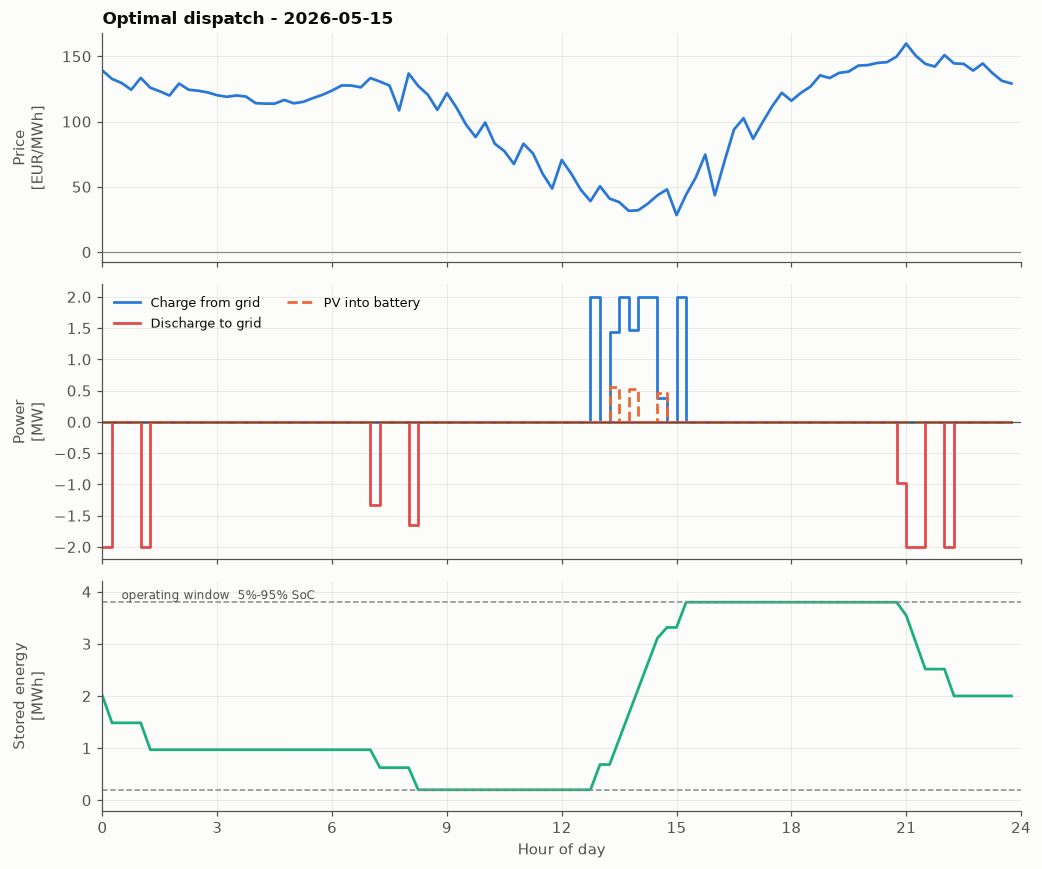

In [13]:
viz.plot_dispatch(sched_ext, CFG, f"Optimal dispatch - {REFERENCE_DAY.date()}")
plt.show()

The three panels share an x-axis on purpose: the schedule is verified by reading downwards.
Discharge coincides with the morning and evening price peaks; charging fills the midday trough,
where the co-located PV contributes alongside grid imports; the state of charge stays inside the
5–95% window and returns to its starting point at midnight, as the terminal condition requires.

Note what the battery does *not* do. It does not cycle on every local price wiggle, even though
several would be profitable against an objective that ignored wear. That restraint is the
degradation term at work, and the next section shows exactly what rule it is enforcing.


In [14]:
# Does forbidding simultaneous charge and discharge change anything?
# Worth testing rather than assuming: it costs a binary per interval and a MILP solve.
MILP = CFG.variant("no-simultaneity", battery=dict(forbid_simultaneous_ch_dis=True))
m_milp, s_milp = build_bess_lp_extended(day_index, prices_day.to_numpy(), pv_day.to_numpy(), MILP)

simultaneous = ((sched_ext["P_ch"] > 1e-6) & (sched_ext["P_dis"] > 1e-6)).sum()
print(f"LP  objective : {model_ext.ObjVal:,.4f} EUR   intervals charging AND discharging: {simultaneous}")
print(f"MILP objective: {m_milp.ObjVal:,.4f} EUR")
print(f"cost of the restriction: {model_ext.ObjVal - m_milp.ObjVal:.6f} EUR")

LP  objective : 616.6693 EUR   intervals charging AND discharging: 0
MILP objective: 616.6693 EUR
cost of the restriction: 0.000000 EUR


The restriction is not binding, and the reason is structural rather than lucky. With
$\eta < 1$ and a positive price, charging and discharging simultaneously destroys energy and
money at once, so the LP relaxation never does it and the binaries buy nothing. The situation
changes when prices go negative, where being paid to consume makes burning energy in the
round-trip loss genuinely attractive — and DK1 does have negative-price intervals. Leaving the
switch in the control panel means the check can be repeated on a day where it might matter,
rather than relying on an argument that holds only most of the time.


## 7 — Reading the solution as a trader

An optimiser that returns a schedule teaches nothing about *why* that schedule. But this is a
linear program, and linear programs come with dual variables, so the rule the model is following
can be recovered exactly rather than guessed at.

Attach a multiplier $\lambda_t$ to the energy balance of interval $t$. It is the marginal value
of one extra MWh stored in the battery at that moment — the storage analogue of a hydro
reservoir's water value, in EUR/MWh. Stationarity of the Lagrangian with respect to the
dispatch variables gives, for any interval where the variable in question sits strictly between
its bounds and no other constraint is active:

$$\frac{\partial \mathcal{L}}{\partial P^{\mathrm{dis}}_t} = 0 \;\;\Longrightarrow\;\; \lambda_t = \eta^{\mathrm{dis}}\left(p_t - \tau^{\mathrm{dis}} - c_{\mathrm{degr}}\right)$$

$$\frac{\partial \mathcal{L}}{\partial P^{\mathrm{ch}}_t} = 0 \;\;\Longrightarrow\;\; \lambda_t = \frac{p_t + \tau^{\mathrm{ch}} + c_{\mathrm{degr}}}{\eta^{\mathrm{ch}}}$$

Eliminating $\lambda$ between an interval where the battery charges at $p_{\mathrm{buy}}$ and one
where it discharges at $p_{\mathrm{sell}}$ yields the condition under which the round trip is
worth doing at all:

$$\boxed{\;p_{\mathrm{sell}} \;\ge\; \frac{p_{\mathrm{buy}} + \tau^{\mathrm{ch}} + c_{\mathrm{degr}}}{\eta^{\mathrm{ch}}\eta^{\mathrm{dis}}} \;+\; \tau^{\mathrm{dis}} \;+\; c_{\mathrm{degr}}\;}$$

That is the entire trading strategy, in one line, and the structure of it is worth pausing on.

Round-trip efficiency enters as a **divisor**, so the euros it costs are proportional to the
purchase price: buying at 100 EUR/MWh, the 94.1% round trip costs about 6 EUR/MWh; buying at
zero it costs nothing. Tariffs and the cost of cycling enter **additively**, so they cost the
same regardless of where prices sit. The practical consequence is that efficiency dominates at
high prices and degradation dominates at low ones — and since the battery buys precisely where
prices are lowest, degradation dominates where it matters. At this configuration, buying near
zero, the cost of cycling contributes more than an order of magnitude more to the required
spread than conversion losses do. Efficiency is the parameter everyone quotes in a datasheet;
degradation is the parameter that decides whether the trade happens.

The claim is testable, so we test it.


In [15]:
# Verify the stationarity conditions numerically on the reference day.
b, mk = CFG.battery, CFG.market
c_degr = CFG.degradation_cost_eur_per_mwh_throughput()
lam = sched_ext["soc_shadow_price"].to_numpy()
tol = 1e-6

# The identities hold only where nothing *else* is active, so filter those intervals out:
# a binding inverter, POI or SoC limit contributes its own multiplier to the balance.
charge_slack = (sched_ext["P_ch"] + sched_ext["P_pv_to_batt"]) < b.p_ch_max_mw - tol
export_slack = sched_ext["net_export"] < CFG.plant.poi_export_limit_mw - tol
import_slack = sched_ext["net_export"] > -CFG.plant.poi_import_limit_mw + tol
soc_slack = (sched_ext["E_end"] > b.e_min_mwh + tol) & (sched_ext["E_end"] < b.e_max_mwh - tol)

interior_dis = (sched_ext["P_dis"] > tol) & (sched_ext["P_dis"] < b.p_dis_max_mw - tol) & export_slack & soc_slack
interior_ch = (sched_ext["P_ch"] > tol) & charge_slack & import_slack & soc_slack

pred_dis = b.eta_dis * (sched_ext["price"] - mk.grid_tariff_discharge_eur_per_mwh - c_degr)
pred_ch = (sched_ext["price"] + mk.grid_tariff_charge_eur_per_mwh + c_degr) / b.eta_ch

err_dis = np.abs(lam[interior_dis.to_numpy()] - pred_dis[interior_dis]).max() if interior_dis.any() else np.nan
err_ch = np.abs(lam[interior_ch.to_numpy()] - pred_ch[interior_ch]).max() if interior_ch.any() else np.nan

print(f"intervals with unconstrained discharge : {int(interior_dis.sum())}  max |lambda - prediction| = {err_dis:.2e}")
print(f"intervals with unconstrained charging  : {int(interior_ch.sum())}  max |lambda - prediction| = {err_ch:.2e}")
print(f"\nmarginal value of stored energy ranges {lam.min():.1f} to {lam.max():.1f} EUR/MWh")
print(f"break-even spread from a 0 EUR/MWh purchase: {CFG.breakeven_spread_eur_per_mwh(0.0):.1f} EUR/MWh")
print(f"  of which round-trip losses : {CFG.breakeven_spread_eur_per_mwh(0.0) - 2 * c_degr:.1f} EUR/MWh")
print(f"  of which cost of cycling   : {2 * c_degr:.1f} EUR/MWh")

intervals with unconstrained discharge : 2  max |lambda - prediction| = 1.42e-14
intervals with unconstrained charging  : 1  max |lambda - prediction| = 0.00e+00

marginal value of stored energy ranges 69.0 to 122.6 EUR/MWh
break-even spread from a 0 EUR/MWh purchase: 48.3 EUR/MWh
  of which round-trip losses : 1.5 EUR/MWh
  of which cost of cycling   : 46.9 EUR/MWh


The duals match the closed form to machine precision. The optimiser is not doing anything
mysterious: it is applying a price rule that fits on one line, and we now have that rule.


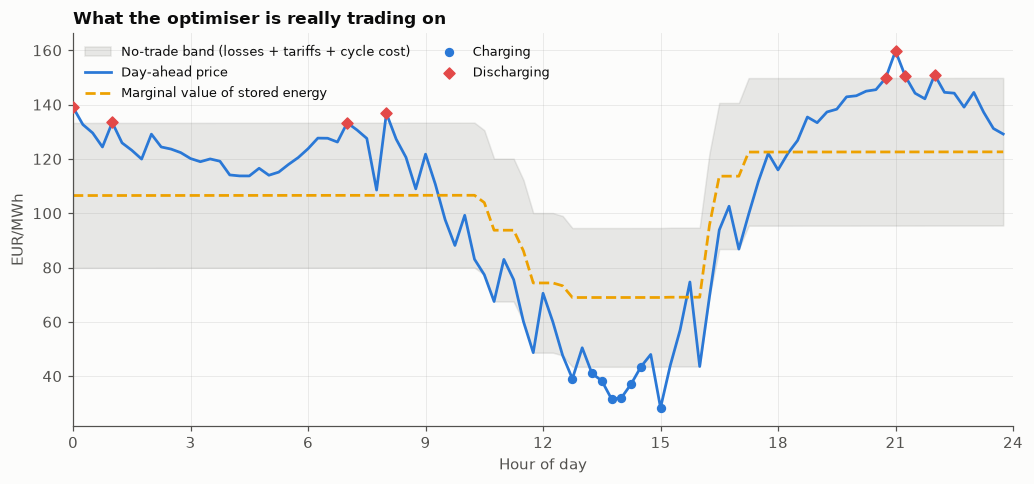

In [16]:
viz.plot_shadow_price(sched_ext, CFG)
plt.show()

This is the picture worth keeping. The dashed line is the marginal value of energy in the
battery; the shaded band around it is the region where neither buying nor selling covers its own
costs. Every charging decision lies below the band and every discharging decision above it, with
nothing in between — the battery is idle for most of the day not because it has nothing to do
but because doing nothing is optimal.

The band's width is the project's real hurdle. Narrow it — cheaper cells, a longer warranty,
lower tariffs, better efficiency — and more of the price curve becomes tradeable. Every
parameter in §2 that matters, matters through this band.

A practical consequence for anyone tuning this model: the shadow price is a *forecast of the
battery's own future*, computed inside the horizon. It is flat wherever the optimiser has no
binding future opportunity and steps exactly where the plan changes. That makes it a far better
diagnostic than the schedule itself when a result looks wrong — a suspiciously flat $\lambda$
usually means a constraint is binding somewhere unexpected.


## 8 — Degradation, counted consistently

Two questions, deliberately separated because conflating them is the standard error in this
literature: *how much of the asset did this schedule consume?* and *what is that worth?*

### 8.1 The unit-cycle problem

Two cycle metrics are in common use and they do not measure the same thing.

* **Equivalent full cycles**: $\text{throughput} / (2 E_{\mathrm{nom}})$. The industry reporting
  convention. Its unit cycle has **100% depth**.
* **Warranted cycles**: counted against a datasheet figure such as *4,000 cycles at 80% DoD*.
  Its unit cycle has depth $\mathrm{DoD}_{\mathrm{ref}}$.

Compare a throughput-based cost against a depth-aware one without reconciling those units and
the depth-aware figure comes out roughly $1/\mathrm{DoD}_{\mathrm{ref}}$ higher — about +25% at
a reference depth of 0.8 — for reasons that have nothing to do with depth of discharge. That is
an artefact, and it is easy to report as a finding.

`bess_opt.degradation` therefore expresses both costs in the **same** unit, the warranted
reference cycle, and derives both from the same half-cycle decomposition of the SoC trajectory.
This yields a property that can be tested:

> at $k = 1$ the throughput-based and depth-aware costs are **identical by construction**.

Any difference between them at $k > 1$ is then genuinely attributable to depth. We verify the
identity before using the depth-aware figure for anything.

### 8.2 The ageing law

Cycles to failure follow the Wöhler-type power law standard in the battery literature:

$$N(\mathrm{DoD}) = N_{\mathrm{ref}}\left(\frac{\mathrm{DoD}_{\mathrm{ref}}}{\mathrm{DoD}}\right)^{k}$$

so a swing of depth $\mathrm{DoD}$ consumes $(\mathrm{DoD}/\mathrm{DoD}_{\mathrm{ref}})^{k}$ of a
warranted cycle. The exponent $k$ carries the whole physical claim: $k=1$ means damage is
proportional to energy and depth is irrelevant; $k>1$ means deep cycles are disproportionately
damaging, which is what mechanical-stress mechanisms such as particle cracking produce. Published
values cluster near 1.0–1.3 for LFP and can exceed 2 for high-nickel NMC.

$k$ is **not calibrated here** — doing so against a real cell dataset is on the roadmap. Until
then it is a parameter to be swept, not a number to be trusted, and it is treated that way below.


In [17]:
half_cycles = dod_half_cycles(sched_ext, CFG.battery.e_nominal_mwh)
print("Half-cycle decomposition of the reference day's SoC trajectory:")
print(half_cycles.round(3).to_string(index=False))

degr = degradation_cost_eur(sched_ext, CFG)
print(f"\nequivalent full cycles (100%-depth unit) : {degr['equivalent_full_cycles']:.3f}")
print(f"warranted cycles, throughput basis       : {degr['reference_cycles_throughput']:.3f}")
print(f"warranted cycles, depth-aware basis      : {degr['reference_cycles_dod_aware']:.3f}")
print(f"cost of one warranted cycle              : {degr['cost_per_reference_cycle_eur']:.2f} EUR")
print(f"\nthroughput-basis cost : {degr['throughput_only_cost_eur']:.2f} EUR")
print(f"depth-aware cost      : {degr['dod_aware_cost_eur']:.2f} EUR   (k = {CFG.degradation.dod_stress_exponent})")
print(f"charged inside the LP : {degr['lp_charged_cost_eur']:.2f} EUR")

assert abs(degr["dod_cost_ratio"] - 1.0) < 1e-9, "at k=1 the two bases must coincide exactly"
print("\nIdentity at k = 1 confirmed: any divergence below is the depth effect, not a unit mismatch.")

Half-cycle decomposition of the reference day's SoC trajectory:
 depth_of_discharge direction
               0.45 discharge
               0.90    charge
               0.45 discharge

equivalent full cycles (100%-depth unit) : 0.900
warranted cycles, throughput basis       : 1.125
warranted cycles, depth-aware basis      : 1.125
cost of one warranted cycle              : 150.00 EUR

throughput-basis cost : 168.75 EUR
depth-aware cost      : 168.75 EUR   (k = 1.0)
charged inside the LP : 168.80 EUR

Identity at k = 1 confirmed: any divergence below is the depth effect, not a unit mismatch.


In [18]:
# How much does depth actually matter? Sweep the exponent on this fixed schedule.
k_rows = []
for k in [1.0, 1.1, 1.25, 1.5, 1.75, 2.0]:
    d = degradation_cost_eur(sched_ext, CFG.variant("k", degradation=dict(dod_stress_exponent=k)))
    k_rows.append({"k": k,
                   "throughput basis [EUR]": d["throughput_only_cost_eur"],
                   "depth-aware [EUR]": d["dod_aware_cost_eur"],
                   "ratio": d["dod_cost_ratio"]})
k_table = pd.DataFrame(k_rows)
print(f"mean half-cycle depth on this day: {degr['mean_depth_of_discharge']:.1%} "
      f"(warranty reference: {CFG.degradation.reference_dod:.0%})")
k_table.round(3)

mean half-cycle depth on this day: 60.0% (warranty reference: 80%)


,k,throughput basis [EUR],depth-aware [EUR],ratio
0,1.00,168.752,168.752,1.000
1,1.10,168.752,165.034,0.978
2,1.25,168.752,159.970,0.948
3,1.50,168.752,152.778,0.905
4,1.75,168.752,146.974,0.871
5,2.00,168.752,142.387,0.844


The direction of this result is the opposite of what one might expect, and the reason is worth
stating plainly.

This day's swings average a depth below the 80% warranty reference. Under a convex ageing law,
cycles shallower than the reference are *less* damaging per MWh than the datasheet implies — so
at $k = 2$ the depth-aware cost sits **below** the throughput-based estimate, not above it. The
conventional throughput metric is conservative for an asset operated gently and optimistic for
one operated hard, and which of those applies is a property of the strategy, not of the cell.

This matters commercially, because it is the mechanism behind warranty negotiation: an operator
who can demonstrate shallow cycling has a genuine argument for more cycles, and one who cannot
should expect the opposite. It is also why §10 reports mean depth of discharge alongside margin
for every strategy — margin alone cannot tell the two cases apart.


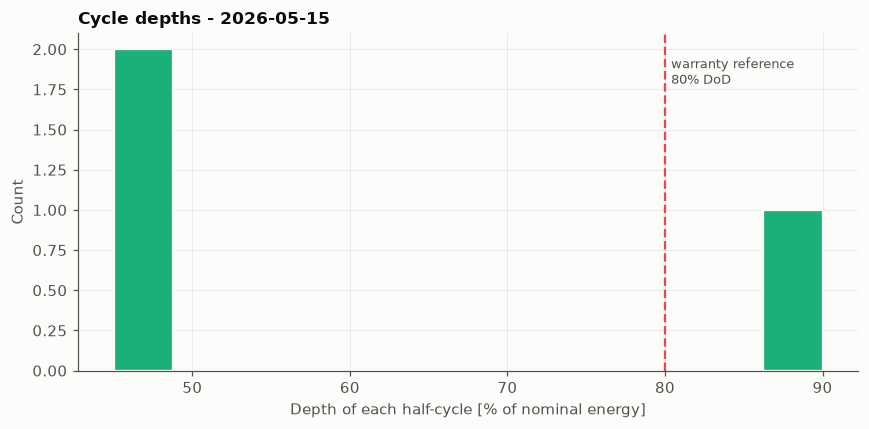

In [19]:
viz.plot_depth_histogram(half_cycles, CFG, f"Cycle depths - {REFERENCE_DAY.date()}")
plt.show()

### 8.3 Where the cost of a cycle comes from

The coefficient $c_{\mathrm{degr}}$ used in the objective is not chosen. It is derived, and the
derivation is short enough to state in full.

Over its warranted life the asset delivers

$$E_{\mathrm{life}} = N_{\mathrm{ref}}\cdot \mathrm{DoD}_{\mathrm{ref}}\cdot E_{\mathrm{nom}} \quad[\text{MWh discharged}]$$

and, counting both directions, moves $2E_{\mathrm{life}}$ MWh of throughput. Consuming the whole
asset costs $\text{CAPEX}\cdot E_{\mathrm{nom}}$, so

$$c_{\mathrm{degr}} = \frac{\text{CAPEX}}{2\,N_{\mathrm{ref}}\,\mathrm{DoD}_{\mathrm{ref}}}$$

$E_{\mathrm{nom}}$ cancels: **the marginal cost of cycling is a property of the chemistry and its
price, not of how large the installation is.** A 4 MWh and a 400 MWh system face the same
EUR/MWh discipline, which is why this quantity is comparable across projects in a way that total
degradation cost is not.

§10 returns to this number and asks whether it is the *right* price to trade at — which, it
turns out, it is not.


In [20]:
print(f"CAPEX                       {CFG.degradation.capex_eur_per_mwh:>12,.0f} EUR/MWh")
print(f"warranted cycles            {CFG.degradation.cycle_life_at_ref_dod:>12,.0f} at {CFG.degradation.reference_dod:.0%} DoD")
print(f"-> cost per warranted cycle {CFG.degradation.cost_per_reference_cycle_eur(CFG.battery.e_nominal_mwh):>12,.2f} EUR")
print(f"-> c_degr                   {c_degr:>12.2f} EUR/MWh of throughput")
print(f"-> required spread          {CFG.breakeven_spread_eur_per_mwh(0.0):>12.2f} EUR/MWh (buying at zero)")

# How sensitive is the whole project to this one derived number?
print("\nSensitivity of c_degr to its two inputs:")
for capex in [100_000, 150_000, 250_000]:
    for life in [4_000, 8_000]:
        v = CFG.variant("x", degradation=dict(capex_eur_per_mwh=capex, cycle_life_at_ref_dod=life))
        print(f"  CAPEX {capex:>7,} EUR/MWh, {life:>5,} cycles -> "
              f"c_degr {v.degradation_cost_eur_per_mwh_throughput():5.1f} EUR/MWh, "
              f"break-even spread {v.breakeven_spread_eur_per_mwh(0.0):5.1f} EUR/MWh")

CAPEX                            150,000 EUR/MWh
warranted cycles                   4,000 at 80% DoD
-> cost per warranted cycle       150.00 EUR
-> c_degr                          23.44 EUR/MWh of throughput
-> required spread                 48.35 EUR/MWh (buying at zero)

Sensitivity of c_degr to its two inputs:
  CAPEX 100,000 EUR/MWh, 4,000 cycles -> c_degr  15.6 EUR/MWh, break-even spread  32.2 EUR/MWh
  CAPEX 100,000 EUR/MWh, 8,000 cycles -> c_degr   7.8 EUR/MWh, break-even spread  16.1 EUR/MWh
  CAPEX 150,000 EUR/MWh, 4,000 cycles -> c_degr  23.4 EUR/MWh, break-even spread  48.3 EUR/MWh
  CAPEX 150,000 EUR/MWh, 8,000 cycles -> c_degr  11.7 EUR/MWh, break-even spread  24.2 EUR/MWh
  CAPEX 250,000 EUR/MWh, 4,000 cycles -> c_degr  39.1 EUR/MWh, break-even spread  80.6 EUR/MWh
  CAPEX 250,000 EUR/MWh, 8,000 cycles -> c_degr  19.5 EUR/MWh, break-even spread  40.3 EUR/MWh


An LFP system at 100,000 EUR/MWh warranted for 8,000 cycles needs a spread of 13 EUR/MWh; an
expensive NMC system at 250,000 EUR/MWh and 4,000 cycles needs 80. Those two assets face
qualitatively different markets — the first trades most days, the second only the volatile ones.
No amount of optimisation sophistication substitutes for that procurement decision, which is
worth remembering before tuning anything else.


## 9 — From one day to a distribution

One day is an anecdote. The backtest solves many independent days — each with perfect foresight
of its own prices and PV, each starting and ending at the same state of charge — and reports the
distribution.

Two properties of this design are deliberate. Days are **independent**, because the terminal-SoC
condition closes each one, which is what licenses treating them as a sample and quoting a
standard error. And foresight is **perfect**, which makes every number here an upper bound: a
real operator commits before knowing the prices, and forecast error bites hardest on exactly the
volatile days that carry the value. §13 puts a number on part of that gap.


In [21]:
days = sample_available_days(prices, CFG)
print(f"{len(days)} days sampled from {days[0].date()} to {days[-1].date()}")

daily, kpi, schedules = run_strategy(CFG, prices, days)
summary_cols = ["gross_margin_eur", "degradation_charged_eur", "economic_margin_eur",
                "equivalent_full_cycles", "discharged_mwh", "captured_spread_eur_per_mwh",
                "mean_depth_of_discharge", "price_std"]
daily[summary_cols].describe().T.round(2)

30 days sampled from 2025-11-21 to 2026-09-13


,count,mean,std,min,25%,50%,75%,max
gross_margin_eur,30.0,777.05,455.17,218.63,458.95,725.73,972.31,2528.14
degradation_charged_eur,30.0,158.52,79.45,0.10,114.51,168.80,185.87,333.82
economic_margin_eur,30.0,618.53,403.56,134.15,384.34,548.90,749.03,2274.89
equivalent_full_cycles,30.0,0.85,0.42,0.00,0.61,0.90,0.99,1.78
discharged_mwh,30.0,3.28,1.64,0.00,2.37,3.49,3.84,6.90
captured_spread_eur_per_mwh,27.0,124.40,53.56,61.27,80.50,128.71,147.76,333.62
mean_depth_of_discharge,30.0,0.46,0.21,0.00,0.32,0.57,0.60,0.71
price_std,30.0,43.29,26.25,6.86,21.91,44.09,56.67,140.91


In [22]:
mean = daily["gross_margin_eur"].mean()
stderr = daily["gross_margin_eur"].std(ddof=1) / np.sqrt(len(daily))
print(f"gross margin   : {mean:,.0f} +/- {stderr:,.0f} EUR/day  (mean +/- 1 s.e.)")
print(f"               : median {daily['gross_margin_eur'].median():,.0f}, "
      f"worst {daily['gross_margin_eur'].min():,.0f}, best {daily['gross_margin_eur'].max():,.0f}")
print(f"relative s.e.  : {stderr / mean:.1%} - differences between strategies smaller than this are noise")
print(f"\ncycles/day     : {daily['equivalent_full_cycles'].mean():.2f}")
print(f"days the battery stayed still: {(daily['equivalent_full_cycles'] < 0.01).sum()}")

# Concentration: how much of the total comes from the best few days?
ranked = daily["gross_margin_eur"].sort_values(ascending=False)
top_share = ranked.head(max(1, len(ranked) // 5)).sum() / ranked.sum()
print(f"share of total margin earned on the best 20% of days: {top_share:.0%}")

gross margin   : 777 +/- 83 EUR/day  (mean +/- 1 s.e.)
               : median 726, worst 219, best 2,528
relative s.e.  : 10.7% - differences between strategies smaller than this are noise

cycles/day     : 0.85
days the battery stayed still: 3
share of total margin earned on the best 20% of days: 37%


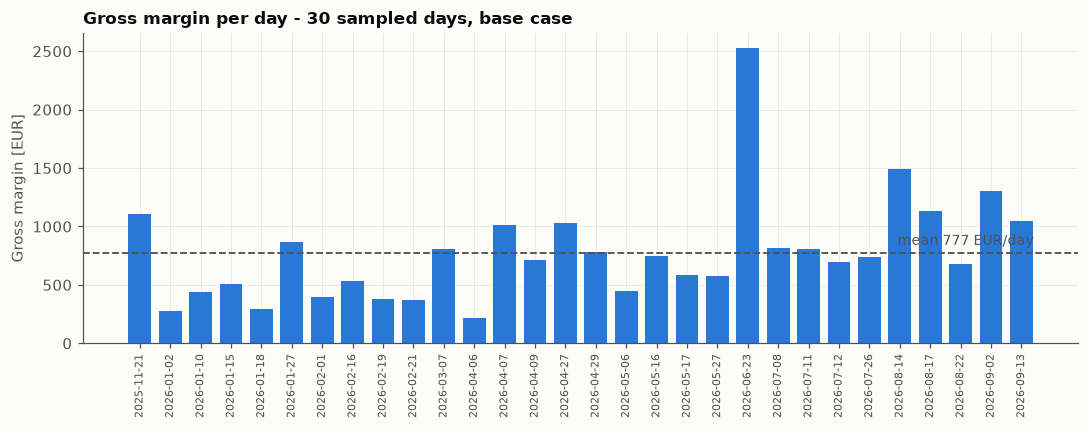

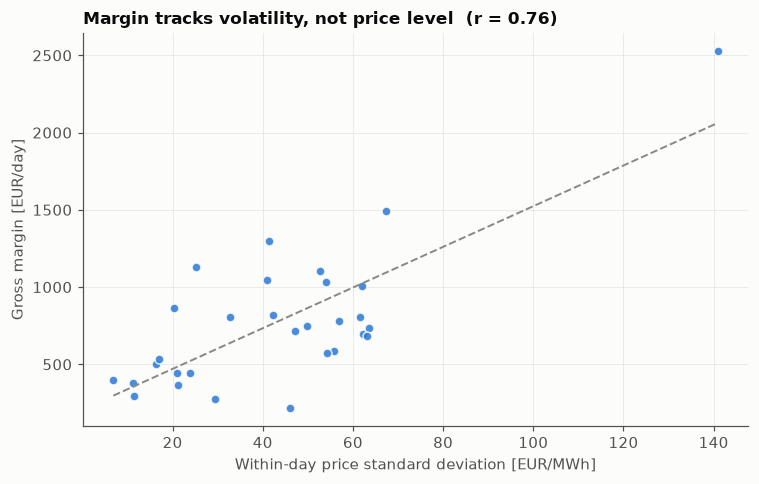

In [23]:
viz.plot_daily_margin(daily, f"Gross margin per day - {len(daily)} sampled days, base case")
plt.show()
viz.plot_margin_vs_volatility(daily)
plt.show()

Two things to take from these figures.

**The relationship with volatility holds**, which is the sanity check: an arbitrage asset is paid
for price *variation*, not price *level*, and a weak correlation here would have meant the model
was earning its money somewhere other than where the formulation says it is.

**The distribution is concentrated.** A fifth of the days carry a disproportionate share of the
annual margin, and several days are worth nothing at all because their spread never clears the
band from §7. This is the statistical reason the standard error above is several percent of the
mean, and the practical reason no single-day result in this notebook should be read as typical.
It is also why the comparison in §10 evaluates every strategy on the *same* days — across a
distribution this skewed, a different sample is easily worth more than a different strategy.


## 10 — The fine-tuning workbench

Everything so far establishes a model. This section is about using it.

A *strategy* here is a `ProjectConfig` — the optimiser contains no trading logic of its own, so
choosing a strategy means choosing assumptions about the asset and what its use costs. Comparing
strategies means solving identical days under different assumptions, which
`experiments.compare_strategies` enforces: one day sample, PV seeded from the calendar date, so
that no strategy can win by drawing better weather.

Three rules are applied throughout, and they are what separate a comparison from a collection of
numbers:

1. **Same days, same weather** — otherwise a few percent of difference is indistinguishable from
   sampling noise.
2. **Cash and economic margin reported separately** — gross margin is money received; economic
   margin deducts the cost of cycling, which is an opportunity cost, not a payment. A strategy
   can raise one while lowering the other, and that tension is the thing worth seeing.
3. **Lifetime reported alongside margin** — a strategy that earns 50% more per year while halving
   the asset's life is not a better strategy, and only the pair reveals it.


In [24]:
STRATEGIES = [
    CFG,
    CFG.variant("Course assumptions",
                battery=dict(soc_min_frac=0.0, soc_max_frac=1.0, soc_terminal_mode="free"),
                plant=dict(poi_export_limit_mw=None, poi_import_limit_mw=None),
                degradation=dict(marginal_cost_mode="off")),
    CFG.variant("Ignore wear (cycle = free)", degradation=dict(marginal_cost_mode="off")),
    CFG.variant("Warranty-protective 15-90%", battery=dict(soc_min_frac=0.15, soc_max_frac=0.90)),
    CFG.variant("Cheap LFP (90k, 8000 cyc)",
                degradation=dict(capex_eur_per_mwh=90_000.0, cycle_life_at_ref_dod=8_000.0)),
    CFG.variant("With network tariffs",
                market=dict(grid_tariff_charge_eur_per_mwh=8.0, grid_tariff_discharge_eur_per_mwh=2.0)),
    CFG.variant("No grid charging (PV only)", plant=dict(allow_grid_charging=False)),
    CFG.variant("4-hour system (8 MWh)", battery=dict(e_nominal_mwh=8.0)),
]

comparison = compare_strategies(STRATEGIES, prices, days)
show = ["gross_margin_eur_per_day", "gross_margin_stderr_eur_per_day", "degradation_cost_eur_per_day",
        "economic_margin_eur_per_day", "equivalent_full_cycles_per_day", "mean_depth_of_discharge",
        "effective_lifetime_years", "lifetime_binding_constraint", "npv_eur", "irr", "lcos_eur_per_mwh"]
comparison[show].round(3)

,gross_margin_eur_per_day,gross_margin_stderr_eur_per_day,degradation_cost_eur_per_day,economic_margin_eur_per_day,equivalent_full_cycles_per_day,mean_depth_of_discharge,effective_lifetime_years,lifetime_binding_constraint,npv_eur,irr,lcos_eur_per_mwh
Base case,777.053,83.102,158.521,618.532,0.845,0.461,5.834,degradation,539483.958,0.327,117.955
Course assumptions,1163.311,98.067,0.000,1163.311,2.934,0.316,2.585,degradation,239875.055,0.301,61.355
Ignore wear (cycle = free),864.532,82.943,0.000,864.532,2.904,0.294,2.631,degradation,27181.782,0.088,66.380
Warranty-protective 15-90%,720.412,75.572,137.303,583.109,0.732,0.395,6.309,degradation,523989.248,0.304,128.323
"Cheap LFP (90k, 8000 cyc)",839.770,83.098,81.556,758.214,1.450,0.383,6.343,degradation,991188.625,0.741,38.714
With network tariffs,737.589,81.648,142.657,594.932,0.761,0.434,6.182,degradation,532587.926,0.312,125.434
No grid charging (PV only),639.721,67.194,100.027,539.694,0.533,0.344,7.361,degradation,525216.518,0.276,157.332
4-hour system (8 MWh),1079.677,115.857,271.506,808.172,0.724,0.430,6.346,degradation,461951.488,0.174,129.208


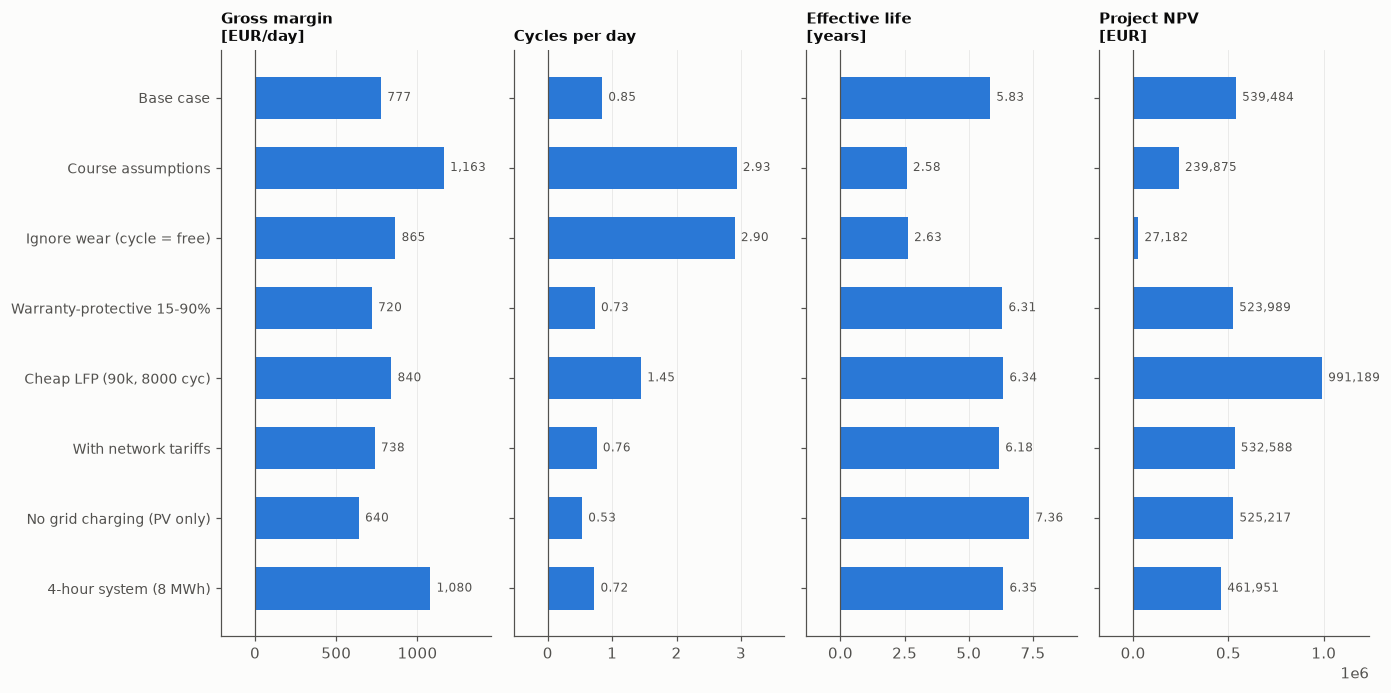

In [25]:
viz.plot_strategy_comparison(
    comparison,
    metrics=("gross_margin_eur_per_day", "equivalent_full_cycles_per_day",
             "effective_lifetime_years", "npv_eur"),
    labels=("Gross margin\n[EUR/day]", "Cycles per day", "Effective life\n[years]", "Project NPV\n[EUR]"),
)
plt.show()

This is the central result of the project, and it is worth reading slowly.

**The strategy with the highest daily margin has among the lowest NPV.** "Course assumptions"
earns roughly 50% more per day than the base case and destroys the asset in about two and a half
years doing it. Its annual revenue is higher and its project value is far lower. A model that
reports only margin ranks it first; a model that reports lifetime ranks it near last. Nothing in
this comparison is subtle — the effect is large, robust to the sampling error, and invisible to
the formulation the exercise starts from.

**Ignoring wear is not free even when wear is not charged.** "Ignore wear" earns more cash per
day than the base case, but its cycles are shallower *and* far more numerous, which shortens the
life without buying depth. It is the clearest illustration that the degradation term is not a
penalty bolted onto the objective: it is the mechanism by which the optimiser chooses *which*
spreads are worth taking.

**Cheap LFP changes the asset's character, not just its price.** A lower CAPEX over a longer
warranty cuts $c_{\mathrm{degr}}$ to about 7 EUR/MWh, which reopens the middle of the price
distribution: the battery trades roughly 70% more, earns more, **and still outlives the base
case**. Nothing about the optimisation changed — only the procurement decision did. No amount of
scheduling sophistication competes with buying the right cells, which is worth remembering before
tuning anything else.

**Tariffs cost close to what the arithmetic predicts.** An 8 EUR/MWh charge on roughly 3.9 MWh
imported and 2 EUR/MWh on 3.3 MWh exported is about 38 EUR/day, and the observed drop is around
40 — the small remainder being trades the wider band no longer justifies. The model's behaviour
is traceable to the rule in §7 rather than to solver idiosyncrasy, which is the point of checking.

**The 4-hour system earns more and is not obviously better.** Doubling energy capacity raises
daily margin by about 39%, but it also doubles the CAPEX, and NPV must be read against that. This
is the one row in the table where the strategies are not comparable at equal cost, and it is
included precisely because that trap is easy to fall into: margin per day is not a ranking.


In [26]:
# Which parameters actually differ between the two most interesting strategies?
diff_configs(CFG, STRATEGIES[1]).rename(columns={"Base case": "base", "Course assumptions": "course"})

name,base,course
battery.soc_min_frac,0.05,0.0
battery.soc_max_frac,0.95,1.0
battery.soc_terminal_mode,equal_to_initial,free
degradation.marginal_cost_mode,derived,off


### 10.1 What price should a cycle carry?

§8.3 derived $c_{\mathrm{degr}}$ from CAPEX and warranted cycle life. That derivation answers
"what does a cycle cost?" — an accounting question. The operating question is different: **at
what price should the optimiser be told a cycle costs, in order to maximise project value?**

These have no reason to be the same number, and they are not. The derived value amortises CAPEX
over the warranted cycle life *assuming that life is consumed exactly over the intended economic
lifetime*. At DK1's volatility that assumption fails badly in one direction: cycling at the
unconstrained rate would burn 4,000 cycles in under three years against a twelve-year economic
life. The scarce resource is not throughput — it is **time**.

So we sweep it. `marginal_cost_mode="manual"` decouples the price charged to the optimiser from
the price implied by the hardware, and every value is evaluated on the same thirty days.


In [27]:
TUNING = CFG.variant("tuning", degradation=dict(marginal_cost_mode="manual"))
cycle_price_grid = [0, 5, 10, 15, 20, 23.44, 30, 40, 50, 60, 75, 90, 120, 150]

cycle_sweep = sensitivity(TUNING, "degradation", "manual_eur_per_mwh_throughput",
                          cycle_price_grid, prices, days)
cols = ["manual_eur_per_mwh_throughput", "gross_margin_eur_per_day", "equivalent_full_cycles_per_day",
        "mean_depth_of_discharge", "annual_gross_margin_eur", "effective_lifetime_years",
        "npv_eur", "irr", "lcos_eur_per_mwh"]
cycle_sweep[cols].round(2)

,manual_eur_per_mwh_throughput,gross_margin_eur_per_day,equivalent_full_cycles_per_day,mean_depth_of_discharge,annual_gross_margin_eur,effective_lifetime_years,npv_eur,irr,lcos_eur_per_mwh
0,0.00,864.53,2.90,0.29,315554.11,2.63,27181.78,0.09,66.38
1,5.00,847.01,1.60,0.37,309159.10,3.88,273378.56,0.26,86.23
2,10.00,826.52,1.25,0.40,301678.47,4.59,388928.48,0.30,96.03
3,15.00,806.49,1.05,0.43,294369.29,5.14,464112.16,0.32,105.03
4,20.00,785.08,0.89,0.46,286553.79,5.66,522759.28,0.33,114.39
5,23.44,777.05,0.85,0.46,283624.17,5.83,539483.96,0.33,117.95
6,30.00,752.75,0.73,0.43,274752.74,6.31,577643.72,0.33,128.40
7,40.00,705.91,0.56,0.34,257657.80,7.18,623173.25,0.32,151.60
8,50.00,687.97,0.51,0.32,251109.65,7.49,632372.88,0.31,161.59
9,60.00,649.82,0.43,0.27,237183.43,8.07,630391.70,0.30,183.46


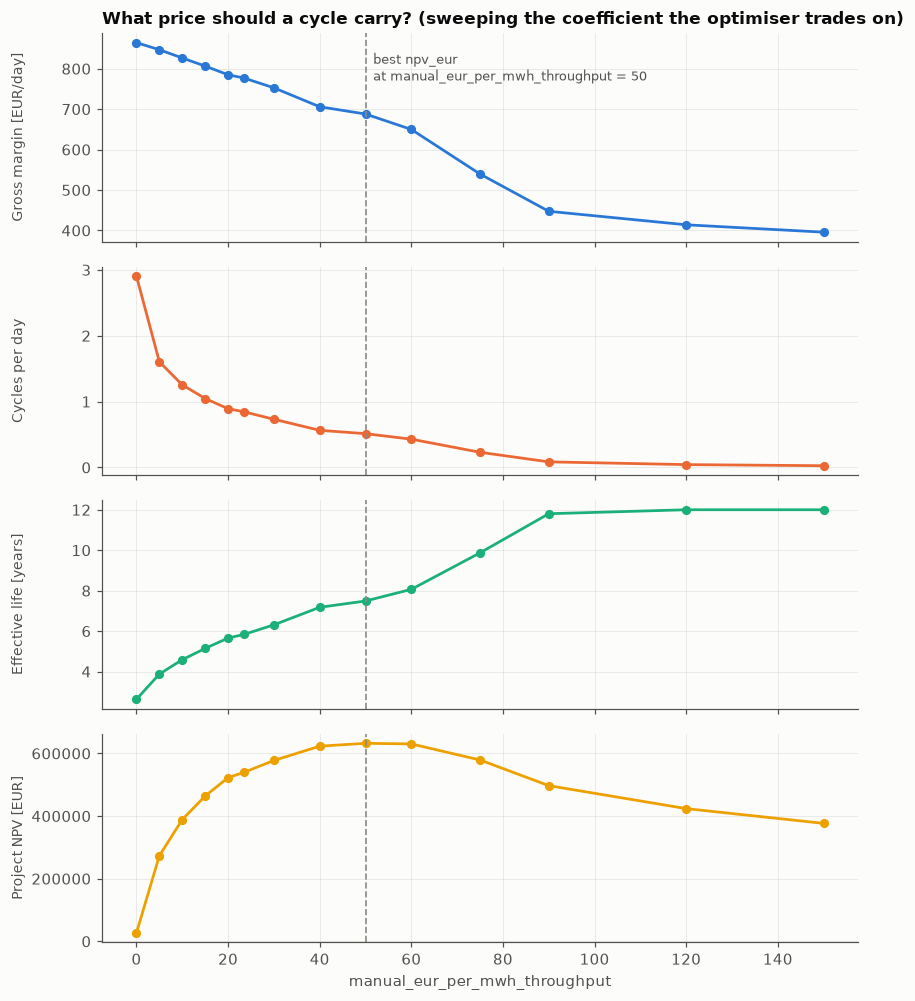

derived from CAPEX and cycle life :  23.44 EUR/MWh  ->  NPV    539,472 EUR
NPV-maximising cycle price        :  50.00 EUR/MWh  ->  NPV    632,373 EUR
value of tuning this one number   :    +92,901 EUR (+17.2%)

at the tuned price the battery cycles 0.51 times/day and lives 7.5 years,
against 2.90 cycles/day and 2.6 years when cycling is free.


In [28]:
viz.plot_sensitivity(
    cycle_sweep, "manual_eur_per_mwh_throughput",
    metrics=("gross_margin_eur_per_day", "equivalent_full_cycles_per_day", "effective_lifetime_years", "npv_eur"),
    labels=("Gross margin [EUR/day]", "Cycles per day", "Effective life [years]", "Project NPV [EUR]"),
    title="What price should a cycle carry? (sweeping the coefficient the optimiser trades on)",
)
plt.show()

best = cycle_sweep.loc[cycle_sweep["npv_eur"].idxmax()]
derived_npv = float(np.interp(c_degr, cycle_sweep["manual_eur_per_mwh_throughput"], cycle_sweep["npv_eur"]))
print(f"derived from CAPEX and cycle life : {c_degr:6.2f} EUR/MWh  ->  NPV {derived_npv:>10,.0f} EUR")
print(f"NPV-maximising cycle price        : {best['manual_eur_per_mwh_throughput']:6.2f} EUR/MWh  ->  NPV {best['npv_eur']:>10,.0f} EUR")
print(f"value of tuning this one number   : {best['npv_eur'] - derived_npv:>+10,.0f} EUR "
      f"({best['npv_eur'] / derived_npv - 1:+.1%})")
print(f"\nat the tuned price the battery cycles {best['equivalent_full_cycles_per_day']:.2f} times/day "
      f"and lives {best['effective_lifetime_years']:.1f} years,")
print(f"against {cycle_sweep.iloc[0]['equivalent_full_cycles_per_day']:.2f} cycles/day and "
      f"{cycle_sweep.iloc[0]['effective_lifetime_years']:.1f} years when cycling is free.")

The NPV curve is unimodal with a clear interior maximum, and the maximum sits well above the
textbook value.

The shape has a clean economic reading. At zero the optimiser trades every spread it can find,
earns the most cash per day, and exhausts the warranty in under three years — high revenue over
a short life, discounted over too few periods to recover the CAPEX. As the charge rises the
battery becomes progressively more selective: margin per day falls, but each remaining trade is
a better one and the asset survives longer. Past the optimum, selectivity turns into paralysis —
the battery declines trades that would have paid, revenue collapses toward zero, and the
lifetime gain no longer compensates.

**The optimum is the point where a marginal year of life is worth exactly a marginal euro of
daily margin.** That trade-off is invisible in the formulation the exercise begins with, because
that formulation contains neither lifetime nor cost of capital.

Two caveats, stated rather than buried. The peak is **flat**: NPV is within a few percent of its
maximum anywhere between roughly 40 and 60 EUR/MWh, and the daily mean it is built on carries a
standard error of about 11%. The defensible reading is therefore *"roughly twice the derived
value, and certainly not the derived value"* — not a specific number to three figures. And the
sweep inherits the backtest's perfect foresight, which flatters aggressive strategies; under
forecast error the optimum should move higher still, since a trade taken on a wrong forecast
consumes the cycle whether or not it earns the spread.


### 10.2 Other parameters worth tuning

The same machinery answers any one-parameter question. Three that matter for a utility-scale
asset, chosen because each has a defensible answer that is not obvious in advance.


In [29]:
sw_window = sensitivity(CFG, "battery", "soc_min_frac", [0.0, 0.05, 0.10, 0.15, 0.20, 0.30], prices, days)
sw_power = sensitivity(CFG, "battery", "p_dis_max_mw", [0.5, 1.0, 2.0, 3.0, 4.0], prices, days)
sw_poi = sensitivity(CFG, "plant", "poi_export_limit_mw", [1.0, 1.5, 2.0, 3.0, 4.0], prices, days)

for name, sw, param in [("SoC floor", sw_window, "soc_min_frac"),
                        ("Discharge power (C-rate)", sw_power, "p_dis_max_mw"),
                        ("POI export limit", sw_poi, "poi_export_limit_mw")]:
    print(f"\n--- {name} ---")
    print(sw[[param, "gross_margin_eur_per_day", "equivalent_full_cycles_per_day",
              "effective_lifetime_years", "npv_eur"]].round(2).to_string(index=False))


--- SoC floor ---
 soc_min_frac  gross_margin_eur_per_day  equivalent_full_cycles_per_day  effective_lifetime_years   npv_eur
         0.00                    792.81                            0.88                      5.71 543594.89
         0.05                    777.05                            0.85                      5.83 539483.96
         0.10                    760.27                            0.81                      5.97 535472.90
         0.15                    743.05                            0.77                      6.12 532012.75
         0.20                    724.46                            0.73                      6.30 528895.63
         0.30                    684.15                            0.65                      6.73 522992.05

--- Discharge power (C-rate) ---
 p_dis_max_mw  gross_margin_eur_per_day  equivalent_full_cycles_per_day  effective_lifetime_years   npv_eur
          0.5                    676.50                            0.67            

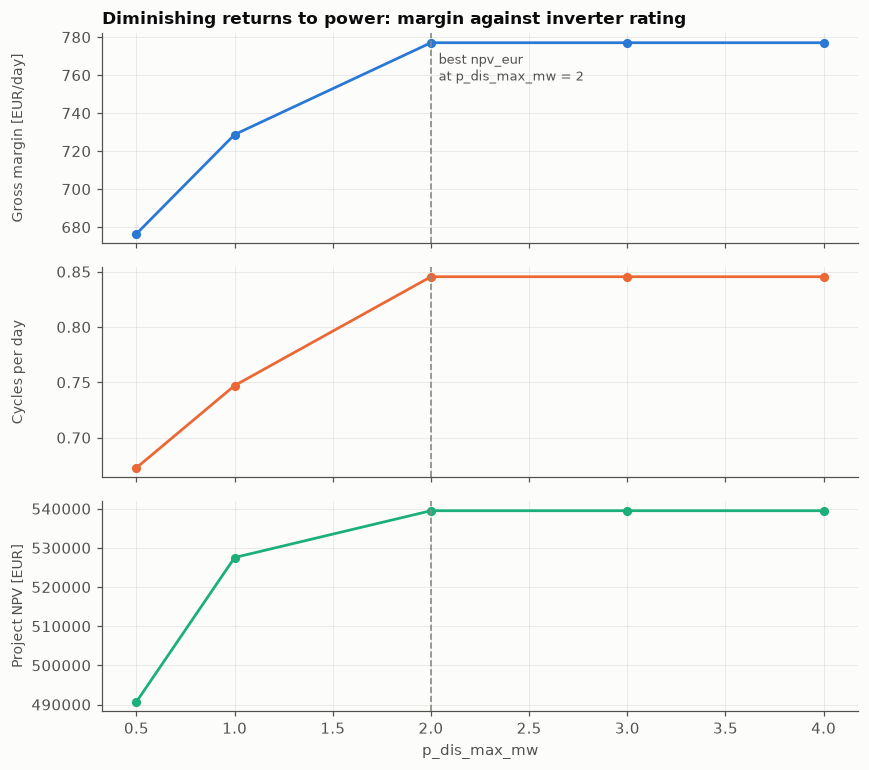

In [30]:
viz.plot_sensitivity(sw_power, "p_dis_max_mw",
                     metrics=("gross_margin_eur_per_day", "equivalent_full_cycles_per_day", "npv_eur"),
                     labels=("Gross margin [EUR/day]", "Cycles per day", "Project NPV [EUR]"),
                     title="Diminishing returns to power: margin against inverter rating")
plt.show()

**The SoC floor never pays for itself inside this model — and that is the useful finding.**
NPV falls monotonically as the floor rises, from 0% upward. Raising it does lengthen the asset's
life, as intended, but not by enough to offset the energy taken out of service: a floor of 20%
buys about half a year of life and costs roughly 7% of daily margin.

The temptation is to conclude that the floor should be zero. That conclusion would be wrong, and
seeing *why* is more instructive than the sweep itself. The floor protects against mechanisms
this model does not represent — accelerated calendar fade at extreme states of charge, cell
imbalance and the difficulty of balancing a pack near empty, and above all the warranty, which is
a contract rather than a physical law and is voided by operating outside the window regardless of
what the cells would have tolerated. An optimiser that cannot see a contract cannot price it.

This is the honest boundary of parameter tuning: the sweep gives the cost of the constraint, and
the cost of a constraint is genuinely worth knowing. It does not give permission to remove it.

**Power saturates, and sharply.** Beyond 2 MW the margin is *identical* to four decimal places —
the inverter has stopped binding entirely. The limit on most days is not how fast the battery can
move energy but how much energy it has and how many hours of good price there are to move it
into. For a 2-hour system on this price distribution, C-rate is not where the next euro is.

**Relaxing the connection limit slightly reduces NPV.** Counter-intuitive, and it is the
lifetime mechanism again: a wider export window lets the battery trade a little more, which earns
a little more per day and consumes the warranty marginally faster, and at this cycle price the
second effect wins. The margins are small enough to sit inside the sampling error, so the
defensible claim is the weaker one — the POI limit is close to non-binding here, which is exactly
the structural argument for co-locating a battery behind a constrained connection in the first
place.

A closing note on method. Every result in this section is a *one-parameter* sweep around one base
case. Parameters interact — the optimal cycle price depends on the SoC window, which depends on
the ageing exponent — so these curves are local gradients, not global prescriptions. That is what
they are for, and reading them as more would be a misuse of them.


## 11 — Is it bankable?

### 11.1 Where degradation belongs, and where it does not

One methodological point has to be settled before any cash flow is computed, because getting it
wrong moves the answer by tens of percent and the error leaves no trace in the output.

The cost of cycling plays **two distinct roles**, and it must be counted in exactly one of them
at a time:

1. **In the operating problem it is an opportunity cost.** Charging $c_{\mathrm{degr}}$ per MWh
   of throughput is what stops the optimiser chasing a 5 EUR/MWh spread with an asset whose
   cycles cost 23. It changes the *schedule*. That is its role in §6–§10.

2. **In the investment case it is the CAPEX.** A discounted cash flow already accounts for the
   asset: it appears in full as the year-zero outflow, and the fact that it wears out appears as
   a finite project life. Subtracting an annual "degradation cost" from the operating margin *on
   top of* that year-zero CAPEX **charges the same asset twice.**

So the cash flows below use the **gross margin** — market revenue net of network tariffs, the
money that actually reaches the bank account — and never deduct degradation from it. What
degradation does here instead is set the horizon:

$$\text{life} = \min\left(L_{\mathrm{econ}},\; \frac{1 - \mathrm{SoH}_{\mathrm{EoL}}}{\underbrace{\frac{(1-\mathrm{SoH}_{\mathrm{EoL}})\,n_{\mathrm{cycles/yr}}}{N_{\mathrm{ref}}}}_{\text{cycling}} + \underbrace{f_{\mathrm{cal}}}_{\text{calendar}}}\right)$$

Cycling harder raises the annual margin and shortens the years over which it is earned. Routing
that trade-off through the **lifetime** rather than through a deducted cost is what makes it
visible — and it is why §10's tuning result exists at all.

One further consequence: calendar fade must stay out of the objective. It accrues whether the
battery trades or sits idle, so it is sunk from the operator's point of view, and asking an
optimiser to avoid a cost it cannot avoid would distort the schedule for nothing. It belongs
here, shortening the life.


In [31]:
life = effective_lifetime_years(kpi["annual_reference_cycles"], CFG)
for k, v in life.items():
    print(f"{k:32s}: {v:,.3f}" if isinstance(v, float) else f"{k:32s}: {v}")

print(f"\nannual gross margin  : {kpi['annual_gross_margin_eur']:,.0f} EUR/yr "
      f"(before availability of {CFG.economics.availability:.0%})")
print(f"annual warranted cycles: {kpi['annual_reference_cycles']:,.0f}/yr against a "
      f"{CFG.degradation.cycle_life_at_ref_dod:,.0f}-cycle warranty")

annual_reference_cycles         : 385.654
cycling_fade_frac_per_year      : 0.019
calendar_fade_frac_per_year     : 0.015
life_from_degradation_years     : 5.834
requested_lifetime_years        : 12.000
effective_lifetime_years        : 5.834
binding_constraint              : degradation

annual gross margin  : 283,624 EUR/yr (before availability of 97%)
annual warranted cycles: 386/yr against a 4,000-cycle warranty


In [32]:
flows = project_cashflows(kpi["annual_gross_margin_eur"], kpi["annual_reference_cycles"], CFG)
# Round per column: capacity fade is a third-decimal quantity and rounding it to whole
# units - as a single .round(0) over the frame would - hides the very effect it records.
flows.round({"year": 2, "period_length_years": 2, "revenue_eur": 0, "opex_eur": 0,
             "capex_eur": 0, "net_cash_flow_eur": 0, "remaining_capacity_frac": 3})

,year,period_length_years,revenue_eur,opex_eur,capex_eur,net_cash_flow_eur,remaining_capacity_frac
0,0.00,0.00,0.0,0.0,-600000.0,-600000.0,1.000
1,1.00,1.00,270400.0,-12000.0,0.0,258400.0,0.983
2,2.00,1.00,260968.0,-12000.0,0.0,248968.0,0.949
3,3.00,1.00,251536.0,-12000.0,0.0,239536.0,0.914
4,4.00,1.00,242105.0,-12000.0,0.0,230105.0,0.880
5,5.00,1.00,232673.0,-12000.0,0.0,220673.0,0.846
6,5.83,0.83,186803.0,-10006.0,0.0,176797.0,0.814


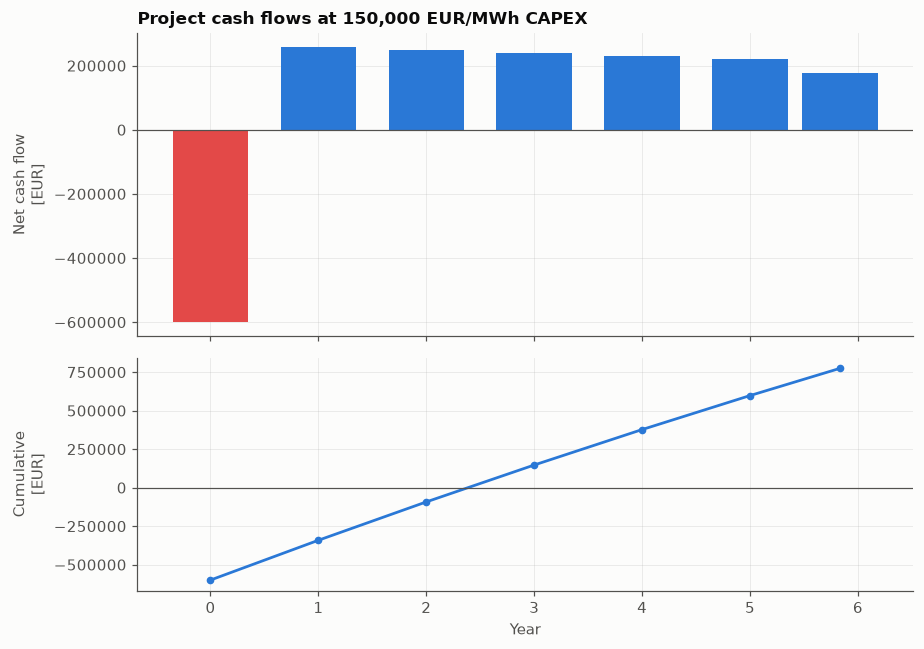

capex_eur_per_mwh             : 150,000.00
capex_total_eur               : 600,000.00
effective_lifetime_years      : 5.83
lifetime_binding_constraint   : degradation
npv_eur                       : 539,483.96
irr                           : 0.33
discounted_payback_years      : 2.67
lcos_eur_per_mwh              : 117.95


In [33]:
viz.plot_cashflows(flows, f"Project cash flows at {CFG.degradation.capex_eur_per_mwh:,.0f} EUR/MWh CAPEX")
plt.show()

result = evaluate_project(kpi["annual_gross_margin_eur"], kpi["annual_reference_cycles"],
                          daily["discharged_mwh"].mean() * 365, CFG)
for k, v in result.items():
    print(f"{k:30s}: {v:,.2f}" if isinstance(v, float) else f"{k:30s}: {v}")

Note the final period is a fraction of a year rather than a whole one. That is not cosmetic:
the asset's life is a continuous quantity, and rounding it to whole years makes NPV jump
discontinuously as a parameter is swept — by enough, in this model, to invert the ranking of two
strategies. The sweeps in §10 would have been unreadable with integer years.

### 11.2 Break-even CAPEX, and a feedback the standard method misses

Nobody knows what a battery costs, so instead of asserting one number we sweep it and report the
quantity an investment committee can act on: **up to what installed cost does this revenue
stream cover this asset?**

The conventional way to run that sweep holds the operating schedule fixed. That is wrong here,
and in an interesting way. CAPEX enters the problem **twice**: as the year-zero outflow, and —
through $c_{\mathrm{degr}}$ — as the price the optimiser puts on a cycle. A cheaper battery is
not merely cheaper; it is one the optimiser rationally cycles harder, earning more margin than
the same schedule would have earned. Holding the schedule fixed therefore *understates* the value
of cheap storage.

We compute both, and measure the gap.


In [34]:
capex_grid = np.linspace(40_000, 320_000, 15)
both = breakeven_capex_both_ways(CFG, capex_grid, prices, days)

print(f"break-even CAPEX, schedule held fixed : {both['breakeven_capex_fixed_schedule']:>10,.0f} EUR/MWh")
print(f"break-even CAPEX, schedule re-optimised: {both['breakeven_capex_reoptimised']:>10,.0f} EUR/MWh")
print(f"difference                             : {both['relative_gap']:>10.1%}")

break-even CAPEX, schedule held fixed :    273,044 EUR/MWh
break-even CAPEX, schedule re-optimised:    291,188 EUR/MWh
difference                             :       6.6%


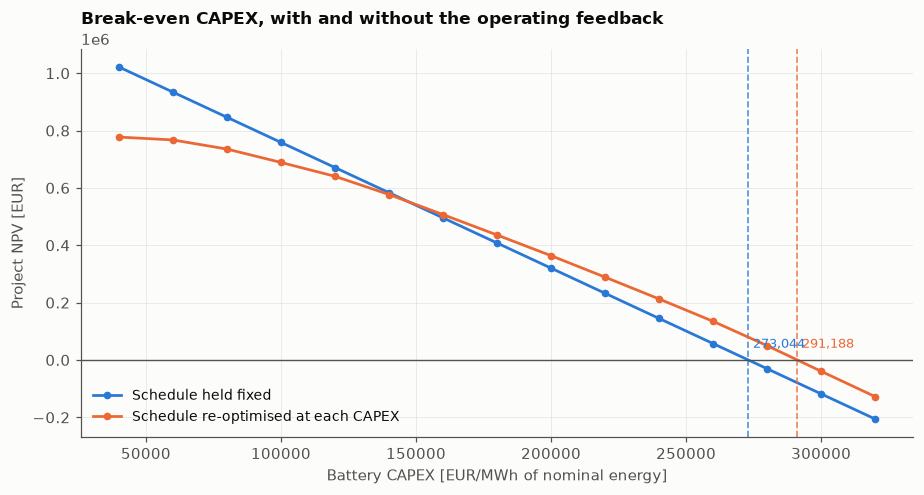

,capex_eur_per_mwh,degradation_cost_eur_per_mwh,gross_margin_eur_per_day,equivalent_full_cycles_per_day,effective_lifetime_years,npv_eur,irr,lcos_eur_per_mwh
0,40000.0,6.25,842.31,1.50,4.07,777339.60,1.72,23.67
1,60000.0,9.38,828.60,1.28,4.52,767308.62,1.10,38.03
2,80000.0,12.50,815.91,1.13,4.90,735470.96,0.78,53.84
3,100000.0,15.62,804.16,1.03,5.20,688869.59,0.59,70.68
4,120000.0,18.75,790.61,0.93,5.53,640463.45,0.46,89.54
5,140000.0,21.88,780.32,0.86,5.76,577057.60,0.37,108.77
6,160000.0,25.00,770.31,0.81,5.97,506931.19,0.29,128.91
7,180000.0,28.12,759.70,0.76,6.18,435900.61,0.24,150.47
8,200000.0,31.25,747.38,0.71,6.41,363737.62,0.19,174.39
9,220000.0,34.38,734.61,0.66,6.65,288861.42,0.15,200.58


In [35]:
viz.plot_capex_breakeven(
    {"Schedule held fixed": both["sweep_fixed_schedule"],
     "Schedule re-optimised at each CAPEX": both["sweep_reoptimised"]},
    {"Schedule held fixed": both["breakeven_capex_fixed_schedule"],
     "Schedule re-optimised at each CAPEX": both["breakeven_capex_reoptimised"]},
    title="Break-even CAPEX, with and without the operating feedback",
)
plt.show()

both["sweep_reoptimised"].round(2)

The two curves separate exactly where the argument says they should: at low CAPEX, where the
re-optimised battery takes advantage of cheap cycles and the fixed schedule cannot.

The break-even figure itself deserves a sceptical reading, and it is worth being explicit about
why rather than presenting it as a result. It rests on **arbitrage revenue only**, on a
**perfect-foresight** backtest, and on a **thirty-day sample** of one price series. Real
utility-scale BESS earn a substantial and often dominant share of their income in frequency and
reserve markets, which this model does not represent at all; that omission pushes the true
break-even up. Perfect foresight pushes it down. The two do not cancel in any principled way.

What the number is genuinely good for is a **sanity check on the whole model chain**: it lands in
the same order of magnitude as observed installed costs for utility-scale Li-ion, which would not
happen if the price data, the efficiency chain, the degradation model or the discounting carried
a serious error. A break-even of 20,000 or 2,000,000 EUR/MWh would tell us something is broken.
That is the claim being made here, and not a stronger one.


In [36]:
# LCOS across the same range, for comparability with published figures.
lcos_rows = []
for capex in [80_000, 120_000, 150_000, 200_000, 250_000]:
    v = CFG.variant("x", degradation=dict(capex_eur_per_mwh=float(capex)))
    d_v, k_v, _ = run_strategy(v, prices, days)
    lcos_rows.append({
        "capex_eur_per_mwh": capex,
        "c_degr_eur_per_mwh": v.degradation_cost_eur_per_mwh_throughput(),
        "cycles_per_day": k_v["equivalent_full_cycles_per_day"],
        "discharged_mwh_per_day": k_v["discharged_mwh_per_day"],
        "effective_life_years": k_v["effective_lifetime_years"],
        "lcos_eur_per_mwh": k_v["lcos_eur_per_mwh"],
        "npv_eur": k_v["npv_eur"],
    })
pd.DataFrame(lcos_rows).round(2)

,capex_eur_per_mwh,c_degr_eur_per_mwh,cycles_per_day,discharged_mwh_per_day,effective_life_years,lcos_eur_per_mwh,npv_eur
0,80000,12.50,1.13,4.39,4.90,53.84,735470.96
1,120000,18.75,0.93,3.60,5.53,89.54,640463.45
2,150000,23.44,0.85,3.28,5.83,117.95,539483.96
3,200000,31.25,0.71,2.75,6.41,174.39,363737.62
4,250000,39.06,0.58,2.24,7.10,248.88,174760.74


LCOS rises steeply with CAPEX and does so faster than the CAPEX itself, because an expensive
battery is also one the optimiser cycles less — fewer discharged MWh over which to spread the
same fixed cost. The two effects compound. This is a genuine property of merchant storage rather
than an artefact: cost and utilisation are not independent when the operating policy is
rational, and any LCOS quoted without stating the assumed cycling regime is under-specified.


## 12 — Reproducibility: the same LP, a second solver, no licence

Gurobi is the right tool for this problem and the one the course uses, but it requires a licence.
The academic one needs a university account and periodic renewal; the one bundled with the pip
package is size-limited. Neither is a reasonable prerequisite for someone who wants to clone a
public repository and check a result.

`bess_opt.model_opensource` therefore implements the extended formulation a second time, against
PuLP and the open-source CBC solver it ships with. Anyone can run it with `pip install pulp`.

The duplication buys more than licence independence. **Two formulations written from the same
mathematics and solved by two unrelated solvers, agreeing to eight significant figures, is
evidence that the objective encodes what this notebook claims it encodes.** A single
implementation can only ever be self-consistent: it will happily return a confident optimum for
a model that quietly differs from the one described in the write-up. The agreement below is
therefore a test, with an assertion, and not a remark.


In [37]:
obj_cbc, sched_cbc = solve_bess_lp_extended_opensource(
    day_index, prices_day.to_numpy(), pv_day.to_numpy(), CFG,
)

print(f"Gurobi  : {model_ext.ObjVal:,.8f} EUR")
print(f"CBC     : {obj_cbc:,.8f} EUR")
print(f"|diff|  : {abs(model_ext.ObjVal - obj_cbc):.3e} EUR "
      f"({abs(model_ext.ObjVal - obj_cbc) / abs(model_ext.ObjVal):.2e} relative)")

# Agreement on the objective is necessary but not sufficient - alternative optima can share a
# value while differing in dispatch, so compare the trajectories too.
soc_gap = float((sched_ext["E"] - sched_cbc["E"]).abs().max())
power_gap = float((sched_ext["P_dis"] - sched_cbc["P_dis"]).abs().max())
print(f"\nmax difference in state of charge : {soc_gap:.2e} MWh")
print(f"max difference in discharge power : {power_gap:.2e} MW")

assert abs(model_ext.ObjVal - obj_cbc) < 1e-4, "the two solvers must agree on the optimum"
print("\nCross-check passed: no result in this notebook depends on holding a Gurobi licence.")

Gurobi  : 616.66930970 EUR
CBC     : 616.66930872 EUR
|diff|  : 9.801e-07 EUR (1.59e-09 relative)

max difference in state of charge : 4.98e-08 MWh
max difference in discharge power : 3.66e-09 MW

Cross-check passed: no result in this notebook depends on holding a Gurobi licence.


## 13 — Scheduling under uncertainty

Everything so far assumed the day's prices and PV were known when the schedule was committed.
They are not. A day-ahead bid is submitted before gate closure, it cannot be conditioned on which
future materialises, and it must remain feasible in all of them. That is a **two-stage stochastic
program**, and the exercise leaves it as an open extension.

**Stage structure.** The market commitment $P^{\mathrm{ch}}, P^{\mathrm{dis}}$ is *here-and-now*:
one trajectory, shared across every scenario. The state of charge is necessarily scenario-indexed
— it is driven by that scenario's own PV. So is curtailment, and that is not a modelling
convenience: spilling PV is a real-time action taken after the generation is observed, and
without it a single shared charge/discharge trajectory is easily **infeasible** across scenarios
whose PV differs, because no fixed discharge profile can make room for every outcome.

$$\max_{P^{\mathrm{ch}},P^{\mathrm{dis}}} \;\; \sum_{s=1}^{S}\pi_s\,\Pi_s\!\left(P^{\mathrm{ch}},P^{\mathrm{dis}},\,E^{(s)},\,P^{\mathrm{PV,curt},(s)}\right)$$

**Two classical measures** of what the uncertainty is worth, both reported because they answer
different questions:

| | Definition | Question it answers |
|---|---|---|
| **RP** | optimum of the stochastic program | what the best single commitment earns in expectation |
| **WS** | $\sum_s \pi_s \max \Pi_s$ — each scenario solved with hindsight | an unattainable upper bound |
| **EEV** | expected profit of the schedule optimised against the *mean* scenario | what ignoring uncertainty costs |
| **EVPI** | $WS - RP \ge 0$ | value of a perfect forecast |
| **VSS** | $RP - EEV \ge 0$ | value of modelling uncertainty at all |

EVPI is the more quoted of the two; **VSS is the more actionable**, because a perfect forecast
cannot be bought and a stochastic optimiser can.


In [38]:
N_SCENARIOS = 3
price_scenarios = make_price_scenarios(prices_day.to_numpy(), n_scenarios=N_SCENARIOS,
                                       seed=CFG.simulation.scenario_seed)
pv_scenarios = {s: synthetic_pv_profile(day_index, capacity_mw=CFG.plant.pv_capacity_mw,
                                        seed=1000 + s).to_numpy()
                for s in price_scenarios}

for s in price_scenarios:
    p_s = price_scenarios[s]["prices"]
    print(f"scenario {s}: prob {price_scenarios[s]['probability']:.2f}, "
          f"mean {p_s.mean():6.1f}, std {p_s.std():5.1f}, spread {p_s.max() - p_s.min():6.1f} EUR/MWh, "
          f"PV {pv_scenarios[s].sum() * DT:.2f} MWh")

scenario 0: prob 0.33, mean  106.5, std  24.4, spread   90.6 EUR/MWh, PV 3.39 MWh
scenario 1: prob 0.33, mean  106.3, std  35.2, spread  134.7 EUR/MWh, PV 8.55 MWh
scenario 2: prob 0.33, mean  106.6, std  46.1, spread  175.7 EUR/MWh, PV 4.19 MWh


In [39]:
# RP - the here-and-now schedule
model_stoch, sched_stoch, shared_schedule = build_bess_lp_stochastic(
    day_index, price_scenarios, pv_scenarios, CFG,
)
RP = model_stoch.ObjVal

# WS - each scenario solved with hindsight
ws_profits = []
for s in price_scenarios:
    m_s, _ = build_bess_lp_extended(day_index, price_scenarios[s]["prices"], pv_scenarios[s], CFG)
    ws_profits.append(price_scenarios[s]["probability"] * m_s.ObjVal)
WS = float(np.sum(ws_profits))

# EEV - optimise against the mean scenario, then commit that schedule and see what happens
mean_prices = np.mean([price_scenarios[s]["prices"] for s in price_scenarios], axis=0)
mean_pv = np.mean([pv_scenarios[s] for s in pv_scenarios], axis=0)
m_ev, sched_ev = build_bess_lp_extended(day_index, mean_prices, mean_pv, CFG)

eev_terms, infeasible = [], []
for s in price_scenarios:
    profit_s, _ = evaluate_fixed_schedule(
        day_index, price_scenarios[s]["prices"], pv_scenarios[s], CFG,
        sched_ev["P_ch"].to_numpy(), sched_ev["P_dis"].to_numpy(),
    )
    if profit_s is None:
        infeasible.append(s)
    else:
        eev_terms.append(price_scenarios[s]["probability"] * profit_s)
EEV = float(np.sum(eev_terms)) if not infeasible else float("nan")

print(f"WS  (perfect foresight, unattainable) : {WS:>9,.2f} EUR")
print(f"RP  (best single commitment)          : {RP:>9,.2f} EUR")
print(f"EEV (commitment ignoring uncertainty) : {EEV:>9,.2f} EUR"
      + (f"   [infeasible in scenarios {infeasible}]" if infeasible else ""))
print(f"\nEVPI = WS - RP  = {WS - RP:>9,.2f} EUR/day  ({(WS - RP) / RP:.1%} of RP)")
if not infeasible:
    print(f"VSS  = RP - EEV = {RP - EEV:>9,.2f} EUR/day  ({(RP - EEV) / RP:.1%} of RP)")
assert WS >= RP - 1e-6, "WS >= RP must hold by construction"
if not infeasible:
    assert RP >= EEV - 1e-6, "RP >= EEV must hold by construction"

WS  (perfect foresight, unattainable) :    630.70 EUR
RP  (best single commitment)          :    627.94 EUR
EEV (commitment ignoring uncertainty) :    626.08 EUR

EVPI = WS - RP  =      2.76 EUR/day  (0.4% of RP)
VSS  = RP - EEV =      1.86 EUR/day  (0.3% of RP)


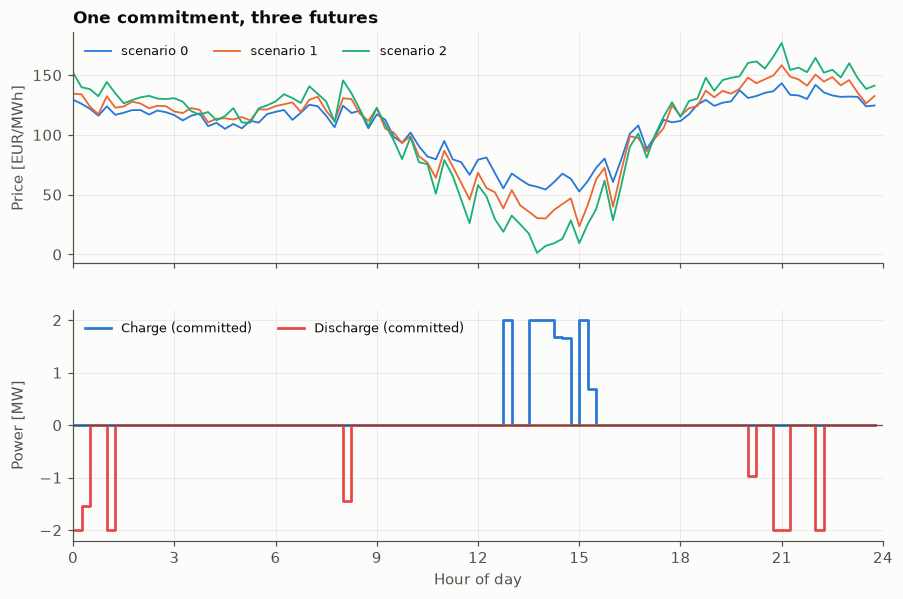

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
hours = shared_schedule["time"].dt.hour + shared_schedule["time"].dt.minute / 60

for s, color in zip(price_scenarios, [viz.PALETTE["price"], viz.PALETTE["pv"], viz.PALETTE["soc"]]):
    axes[0].plot(hours, price_scenarios[s]["prices"], color=color, linewidth=1.2, label=f"scenario {s}")
axes[0].set_ylabel("Price [EUR/MWh]")
axes[0].set_title("One commitment, three futures")
axes[0].legend(ncols=3, fontsize=8.5)

axes[1].step(hours, shared_schedule["P_ch"], where="post", color=viz.PALETTE["charge"], label="Charge (committed)")
axes[1].step(hours, -shared_schedule["P_dis"], where="post", color=viz.PALETTE["discharge"], label="Discharge (committed)")
axes[1].axhline(0, color=viz.PALETTE["ink_soft"], linewidth=0.8)
axes[1].set_ylabel("Power [MW]")
axes[1].set_xlabel("Hour of day")
axes[1].set_xlim(0, 24); axes[1].set_xticks(range(0, 25, 3))
axes[1].legend(ncols=2, fontsize=8.5)
fig.align_ylabels(axes)
plt.show()

### 13.1 A negative result, and what it is actually telling us

**EVPI and VSS both come out near zero** — well under 1% of daily margin. Taken at face value
that would say a perfect price forecast is worth almost nothing to a battery, which is plainly
false. So the number is not a finding about storage; it is a finding about the **scenario
generator**, and it is worth chasing down rather than reporting.

`make_price_scenarios` rescales the *volatility* of an observed day around its mean. Every
scenario therefore agrees on **when** prices are high and disagrees only on **how high**. But a
battery's schedule is overwhelmingly a decision about *timing* — buy in the trough, sell in the
peak — and timing is exactly what these scenarios hold fixed. A single commitment does nearly as
well as hindsight because there was almost nothing to be uncertain about.

That suggests an immediate test: build scenarios that disagree about *when* the peak falls, and
see whether EVPI responds.


In [41]:
# Same machinery, scenarios that disagree on timing rather than on amplitude.
# Rolling the price curve shifts the peak by a few hours - a crude stand-in for the error a
# real day-ahead forecast makes, and the kind of error a fixed commitment cannot absorb.
SHIFTS_INTERVALS = [-8, 0, 8]   # -2 h, on time, +2 h at 15-minute resolution

timing_scenarios = {
    s: {"probability": 1.0 / len(SHIFTS_INTERVALS),
        "prices": np.roll(prices_day.to_numpy(), shift)}
    for s, shift in enumerate(SHIFTS_INTERVALS)
}
timing_pv = {s: pv_day.to_numpy() for s in timing_scenarios}   # hold PV fixed to isolate price timing

m_t, _, shared_t = build_bess_lp_stochastic(day_index, timing_scenarios, timing_pv, CFG)
RP_t = m_t.ObjVal
WS_t = float(np.sum([timing_scenarios[s]["probability"]
                     * build_bess_lp_extended(day_index, timing_scenarios[s]["prices"], timing_pv[s], CFG)[0].ObjVal
                     for s in timing_scenarios]))

mean_prices_t = np.mean([timing_scenarios[s]["prices"] for s in timing_scenarios], axis=0)
_, sched_ev_t = build_bess_lp_extended(day_index, mean_prices_t, pv_day.to_numpy(), CFG)
eev_t, infeasible_t = [], []
for s in timing_scenarios:
    profit_s, _ = evaluate_fixed_schedule(day_index, timing_scenarios[s]["prices"], timing_pv[s], CFG,
                                          sched_ev_t["P_ch"].to_numpy(), sched_ev_t["P_dis"].to_numpy())
    if profit_s is None:
        infeasible_t.append(s)
    else:
        eev_t.append(timing_scenarios[s]["probability"] * profit_s)
EEV_t = float(np.sum(eev_t)) if not infeasible_t else float("nan")

def _uncertainty_metrics(ws, rp, eev):
    return {"WS [EUR]": ws, "RP [EUR]": rp, "EEV [EUR]": eev,
            "EVPI [EUR]": ws - rp, "EVPI [% of RP]": 100 * (ws - rp) / rp,
            "VSS [EUR]": rp - eev, "VSS [% of RP]": 100 * (rp - eev) / rp}

comparison_uncertainty = pd.DataFrame({
    "amplitude uncertain, timing known": _uncertainty_metrics(WS, RP, EEV),
    "timing uncertain (+/- 2 h)": _uncertainty_metrics(WS_t, RP_t, EEV_t),
})
comparison_uncertainty.round(2)

,"amplitude uncertain, timing known",timing uncertain (+/- 2 h)
WS [EUR],630.70,634.82
RP [EUR],627.94,571.94
EEV [EUR],626.08,560.15
EVPI [EUR],2.76,62.88
EVPI [% of RP],0.44,10.99
VSS [EUR],1.86,11.79
VSS [% of RP],0.30,2.06


The response is decisive: holding amplitude uncertain and timing certain makes uncertainty
almost worthless, while making timing uncertain makes it expensive. **The value of a price
forecast to a battery lies in knowing *when*, not *how much*.**

That is a genuinely useful conclusion for anyone building the forecasting half of this problem,
and it has a direct methodological consequence for §13's headline numbers: the amplitude-based
EVPI and VSS in the table above are **not conservative estimates of the true values — they are
artefacts of a scenario generator that failed to represent the uncertainty that matters.**
Reporting them alone would have been misleading, which is why both columns appear.

It also sharpens the roadmap. Replacing the perturbation scheme with scenarios drawn from a
fitted price model is not a refinement; it is the difference between a stochastic program that
measures something and one that does not. That connects directly back to the machine-learning
half of course 46765 — and the requirement is specific: such a model must get the *shape* of the
day right, and be scored on it, since a forecast with excellent RMSE and a mistimed peak is
worth nothing here.

Two caveats remain on the timing column. The shifts are a crude proxy for forecast error rather
than a calibrated error distribution, and three scenarios is a small tree. Both inflate the
uncertainty in the estimate without changing the qualitative conclusion, which is robust to the
size of the shift.


## 14 — What this model still cannot say

Stated plainly, because a model's limitations are part of its result.

**Arbitrage only.** No frequency or reserve revenue. Real utility-scale BESS often earn more from
reserve capacity than from energy arbitrage, and the associated power de-rating would also change
the *schedule*, not merely add a revenue line. Every economic figure here is conservative for
that reason, and the break-even CAPEX correspondingly low.

**Perfect foresight within the day.** §9 solves each day knowing its own prices. §13 begins to
address this but on perturbation scenarios rather than genuine forecasts. Published estimates put
realised arbitrage revenue somewhere around 10–30% below the perfect-foresight bound; nothing
here contradicts that, and nothing here measures it.

**A price-taking, deterministic market.** The battery is assumed not to move the price it trades
at. Defensible at 2 MW; not at portfolio scale, where a fleet's charging depresses the trough it
is charging into.

**An illustrative ageing law.** The exponent $k$ is swept, not fitted. Calendar fade is linear and
independent of state of charge and temperature, which is known to be wrong in a direction that
matters: parking a battery at high SoC in a warm climate ages it materially faster, and this
model would not notice.

**Peak-valley cycle counting.** Exact for the smooth trajectories a day-ahead schedule produces,
but not full rainflow counting. A rolling-horizon or reserve-stacking extension would produce
noisier trajectories where the difference starts to matter.

**Synthetic PV.** Physically motivated but uncorrelated with the price series. Real PV and real
prices are negatively correlated through regional generation, and that correlation is
revenue-relevant: sunny hours are cheap hours.

**No augmentation.** Real projects add capacity mid-life rather than retiring at 80% SoH. Modelling
that would extend the life and change the CAPEX profile.

**A thirty-day sample of one bidding zone and one year.** Relative standard error on the mean
daily margin is several percent, and seasonal coverage is partial.

### Roadmap

In rough order of how much each would change the conclusions:

1. **Revenue stacking** (FCR/aFRR capacity alongside arbitrage, with power de-rating) — the
   largest omission by value, and a second linear term in the same objective.
2. **Rolling horizon with forecast error** — replaces the perfect-foresight bound with a
   realisable number. `bess_opt.backtest` already separates the single-day solve from the day
   loop, which is the seam.
3. **Endogenous, calibrated degradation** — fit $k$ to a public cell dataset and embed the
   depth-aware cost *inside* the LP as a convex piecewise-linear term, so the optimiser trades
   depth against revenue directly rather than through a single throughput coefficient.
4. **Price forecasting feeding the scenarios** — the natural bridge back to the machine-learning
   half of course 46765, and the fix for §13's main weakness.
5. **Full rainflow counting**, once trajectories are noisy enough for it to matter.
6. **Real measured PV**, the moment a clearly-licensed dataset is available.


## 15 — Acknowledgements, sources and use of AI

### Provenance of the work

The problem statement and the baseline formulation in §4.1 follow the BESS day-ahead scheduling
exercise from DTU course *46765 – Machine Learning for Energy Systems*. That formulation is
reproduced faithfully in `bess_opt.model.build_bess_lp` and deliberately left unmodified.

Everything else was developed independently for this project: the extended formulation and its
switchable realism terms (§4.2–§4.3), the duality analysis and break-even condition (§7), the
consistently-anchored degradation model (§8), the experiment framework and the cycle-price
tuning result (§10), the lifetime-linked economics (§11), the open-source cross-check (§12), and
the stochastic implementation with EVPI and VSS (§13).

### Data

Day-ahead prices: **Energinet**, [Energi Data Service](https://www.energidataservice.dk/tso-electricity/DayAheadPrices),
dataset `DayAheadPrices`, price area DK1, published under **CC-BY 4.0**. Attribution as required:
*Source: Energinet (www.energidataservice.dk)*. PV production is synthetic — see §3 and
`data/README.md` for the licensing reasoning behind that choice.

### Use of AI

In line with DTU's rules on the use of generative AI in coursework, this is stated explicitly
rather than left to inference.

I used **Claude (Anthropic)** as a pair-programming and editing assistant while building this
project: refactoring the codebase into documented modules, drafting and revising explanatory
prose, and reviewing the implementation for errors. Several of the substantive corrections
recorded in this notebook — the unit-anchoring artefact in the degradation comparison (§8.1), the
double-counting of degradation in the discounted cash flow (§11.1), and the discontinuity
introduced by rounding asset life to whole years (§11.1) — were identified during that review
process.

What AI did **not** do is decide what this project should investigate or what its results mean.
The modelling choices, the parameter values, the interpretation of every result, and the
judgement about which simplifications are acceptable are mine, and I can defend each of them.
Every numerical claim in this notebook is produced by the code in this repository and can be
reproduced by re-running it; the duality identities in §7, the $k=1$ degradation identity in
§8.1, the generalisation check in §6 and the two-solver cross-check in §12 are all machine-checked
assertions rather than statements of belief, which is the standard I have tried to hold the whole
document to.

### References

- Energinet, *Energi Data Service* — day-ahead price data, CC-BY 4.0.
- Gurobi Optimization, *Gurobi Optimizer Reference Manual*.
- COIN-OR, *CBC (Coin-or Branch and Cut)*, via [PuLP](https://coin-or.github.io/pulp/).
- Birge, J. R. & Louveaux, F., *Introduction to Stochastic Programming* — for the RP / WS / EEV
  framework and the definitions of EVPI and VSS used in §13.
- ASTM E1049, *Standard Practices for Cycle Counting in Fatigue Analysis* — the rainflow
  reference against which §8's simplified peak-valley counting is positioned.


In [42]:
# Reproducibility footer: the exact assumptions behind every figure above.
import platform
print(f"python {platform.python_version()} · numpy {np.__version__} · pandas {pd.__version__}")
print(f"price data: {prices.index.min().date()} to {prices.index.max().date()}, "
      f"{len(prices):,} intervals")
print(f"backtest  : {len(days)} days, seed {CFG.simulation.day_sample_seed}")
print(f"\nconfiguration '{CFG.name}':")
CFG.key_figures().to_frame("value").round(3)

python 3.12.3 · numpy 2.5.3 · pandas 3.0.5
price data: 2025-10-01 to 2026-09-18, 33,884 intervals
backtest  : 30 days, seed 32

configuration 'Base case':


,value
duration [h],2.000
"C-rate, charge [1/h]",0.500
usable energy [MWh],3.600
usable fraction of nameplate [-],0.900
round-trip efficiency [-],0.941
degradation cost [EUR/MWh throughput],23.438
break-even spread from 0 EUR/MWh [EUR/MWh],48.347
installed cost of storage [EUR],600000.000
